In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [2]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [3]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [4]:
# Per la matrice di correlazione :
jet_features = ['logpt', 'eta', 'phi', 'mass']

met_features = [
    'MET_logpt', 'MET_phi', 'MET_covXX', 'MET_covXY',
    'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered'
]

df["jet1_logpt"] = jets[:,0,0]
df["jet1_eta"]   = jets[:,0,1]
df["jet1_phi"]   = jets[:,0,2]
df["jet1_mass"]  = jets[:,0,3]

df["jet2_logpt"] = jets[:,1,0]
df["jet2_eta"]   = jets[:,1,1]
df["jet2_phi"]   = jets[:,1,2]
df["jet2_mass"]  = jets[:,1,3]

df["jet3_logpt"] = jets[:,2,0]
df["jet3_eta"]   = jets[:,2,1]
df["jet3_phi"]   = jets[:,2,2]
df["jet3_mass"]  = jets[:,2,3]


met_features = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

for i, name in enumerate(met_features):
    df[name] = met[:,0,i]




df_H["jet1_logpt"] = jets_H[:,0,0]
df_H["jet1_eta"]   = jets_H[:,0,1]
df_H["jet1_phi"]   = jets_H[:,0,2]
df_H["jet1_mass"]  = jets_H[:,0,3]

df_H["jet2_logpt"] = jets_H[:,1,0]
df_H["jet2_eta"]   = jets_H[:,1,1]
df_H["jet2_phi"]   = jets_H[:,1,2]
df_H["jet2_mass"]  = jets_H[:,1,3]

df_H["jet3_logpt"] = jets_H[:,2,0]
df_H["jet3_eta"]   = jets_H[:,2,1]
df_H["jet3_phi"]   = jets_H[:,2,2]
df_H["jet3_mass"]  = jets_H[:,2,3]


for i, name in enumerate(met_features):
    df_H[name] = met_H[:,0,i]

In [5]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [6]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [7]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [8]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [9]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [10]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [11]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [12]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [13]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [14]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [15]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [16]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [17]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [18]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [19]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [20]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


In [21]:
# Sistemo i nomi delle colonne sbagliate :
# ========= DY =========
df_DY_event = df_DY_event.copy()

# reco
df_DY_event["tau1_pt_reco"] = np.exp(df_DY_event["tau1_logpt"])
df_DY_event["tau2_pt_reco"] = np.exp(df_DY_event["tau2_logpt"])

# gen 
df_DY_event["tau1_pt_gen"] = df_DY_event["gen_tau1_logpt"]
df_DY_event["tau2_pt_gen"] = df_DY_event["gen_tau2_logpt"]

# ========= Higgs =========
df_H_event = df_H_event.copy()

df_H_event["tau1_pt_reco"] = np.exp(df_H_event["tau1_logpt"])
df_H_event["tau2_pt_reco"] = np.exp(df_H_event["tau2_logpt"])

df_H_event["tau1_pt_gen"] = df_H_event["gen_tau1_logpt"]
df_H_event["tau2_pt_gen"] = df_H_event["gen_tau2_logpt"]


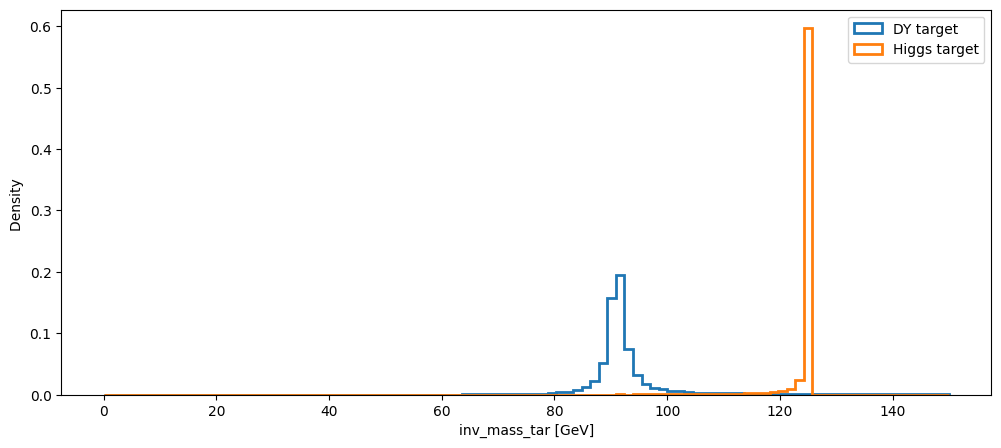

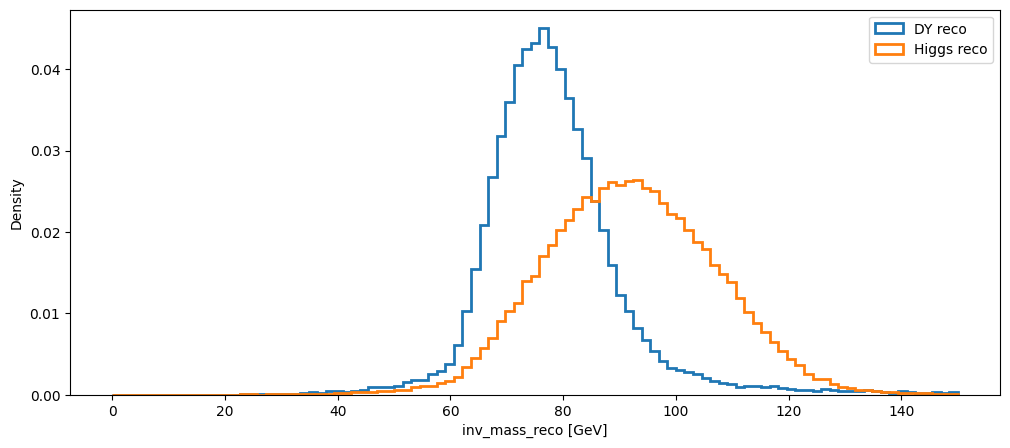

In [22]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0, 150, 100)

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="DY target", linewidth = 2)
plt.hist(df_H_event["inv_mass_tar"], bins=bins, histtype="step", density=True, label="Higgs target", linewidth = 2)
plt.xlabel("inv_mass_tar [GeV]")
plt.ylabel("Density ")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df_DY_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="DY reco",linewidth = 2)
plt.hist(df_H_event["inv_mass_reco"], bins=bins, histtype="step", density=True, label="Higgs reco",linewidth = 2)
plt.xlabel("inv_mass_reco [GeV]")
plt.ylabel("Density")
plt.legend()
plt.show()


# Model

In [23]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [24]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [25]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [26]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [27]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco_corrPNet"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


# Model

# 1. Balanced vs Unbalanced

In [28]:
import copy
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------
# Dataset
# -----------------------
class TabularFMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# -----------------------
# Time embedding 
# -----------------------
class FourierTimeEmbedding(nn.Module):
    def __init__(self, embed_dim=64, max_freq=10.0):
        super().__init__()
        assert embed_dim % 2 == 0
        freqs = torch.linspace(1.0, max_freq, embed_dim // 2)
        self.register_buffer("freqs", freqs)

    def forward(self, t):
        # t: (B,) in [0,1]
        # returns (B, embed_dim)
        angles = 2.0 * math.pi * t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


# -----------------------
# Conditional velocity field v_theta(t, x_t, context)
# -----------------------
class ConditionalVelocityField(nn.Module):
    def __init__(
        self,
        x_dim: int,          # y-dim (2)
        context_dim: int,    # len(train_cols)
        hidden=(256, 256, 256),
        time_embed_dim=64,
        dropout=0.0,
    ):
        super().__init__()
        self.time_embed = FourierTimeEmbedding(embed_dim=time_embed_dim, max_freq=10.0)

        in_dim = x_dim + context_dim + time_embed_dim
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, x_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x_t, context):
        # t: (B,)
        # x_t: (B, x_dim)
        # context: (B, context_dim)
        t_emb = self.time_embed(t)
        inp = torch.cat([x_t, context, t_emb], dim=-1)
        return self.net(inp)


# -----------------------
# Flow Matching loss (linear path)
# -----------------------
def fm_loss(model, context, x1, device):
    """
    context: (B, C)
    x1: (B, x_dim)   target (scaled y, possibly log-transformed)
    """
    B, x_dim = x1.shape
    t = torch.rand(B, device=device)  # Uniform(0,1)
    x0 = torch.randn(B, x_dim, device=device)  # base N(0,I)

    x_t = (1.0 - t)[:, None] * x0 + t[:, None] * x1
    v_star = x1 - x0

    v_pred = model(t, x_t, context)
    return torch.mean((v_pred - v_star) ** 2)


# -----------------------
# Sampling: integrate ODE from t=0 to t=1
# -----------------------
@torch.no_grad()
def sample_y(model, context, n_steps=50, device="cpu"):
    """
    context: (B, C) torch.float32
    returns x1_hat: (B, x_dim)
    """
    model.eval()
    B = context.shape[0]
    x_dim = model.net[-1].out_features

    x = torch.randn(B, x_dim, device=device)  # x(t=0)
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((B,), k * dt, device=device)
        v = model(t, x, context)
        x = x + dt * v  # Euler

    return x  # approx x(t=1)


In [80]:
# OLD

def make_balanced_df(df_all, class_col="class", seed=42):
    # downsample majority class to match minority
    df0 = df_all[df_all[class_col] == 0]
    df1 = df_all[df_all[class_col] == 1]
    n = min(len(df0), len(df1))
    df0b = df0.sample(n=n, random_state=seed, replace=False)
    df1b = df1.sample(n=n, random_state=seed, replace=False)
    return pd.concat([df0b, df1b], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


def split_80_10_10(df, seed=42):
    df_train, df_tmp = train_test_split(df, test_size=0.20, random_state=seed, shuffle=True)
    df_val, df_test  = train_test_split(df_tmp, test_size=0.50, random_state=seed, shuffle=True)
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.count = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.count = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False  # do not stop
        else:
            self.count += 1
            return self.count >= self.patience  # stop if patience exceeded


def prepare_arrays(df_train, df_val, df_test, train_cols, y_cols, log_y=True):
    # X
    X_train = df_train[train_cols].to_numpy()
    X_val   = df_val[train_cols].to_numpy()
    X_test  = df_test[train_cols].to_numpy()

    # y
    y_train = df_train[y_cols].to_numpy()
    y_val   = df_val[y_cols].to_numpy()
    y_test  = df_test[y_cols].to_numpy()

    if log_y:
        # clip to avoid log(0)
        eps = 1e-12
        y_train = np.log(np.clip(y_train, eps, None))
        y_val   = np.log(np.clip(y_val, eps, None))
        y_test  = np.log(np.clip(y_test, eps, None))

    # standardize (fit ONLY on train)
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train)
    X_val_s   = x_scaler.transform(X_val)
    X_test_s  = x_scaler.transform(X_test)

    y_train_s = y_scaler.fit_transform(y_train)
    y_val_s   = y_scaler.transform(y_val)
    y_test_s  = y_scaler.transform(y_test)

    return (X_train_s, X_val_s, X_test_s,
            y_train_s, y_val_s, y_test_s,
            x_scaler, y_scaler)


def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    seed=42,
    log_y=True,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # balanced/unbalanced
    if balanced:
        df_use = make_balanced_df(df_all, class_col=class_col, seed=seed)
    else:
        df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # split 80/10/10
    df_train, df_val, df_test = split_80_10_10(df_use, seed=seed)

    # arrays + scalers
    (Xtr, Xva, Xte,
     ytr, yva, yte,
     x_scaler, y_scaler) = prepare_arrays(df_train, df_val, df_test, train_cols, y_cols, log_y=log_y)

    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    # model
    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        # ---- val ----
        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # early stopping
        stop = stopper.step(val_loss, model)
        if stop:
            break

    # restore best
    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # final test loss 
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    out = {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
    }
    return out


In [108]:
# NEW: utilities + training + SCALING-CONTROL plots

# ---------------------------------------------------------------------------------------
#   NEW NEW: modifico per accettare anche i pesi -> per dopo (fine-tuning)
#             
# ---------------------------------------------------------------------------------------
import copy
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def make_balanced_df(df, class_col="class", seed=42):
    """
    Downsample the majority class to match the minority class.
    Returns a shuffled balanced dataframe.
    """
    df0 = df[df[class_col] == 0]  # DY
    df1 = df[df[class_col] == 1]  # Higgs
    n = min(len(df0), len(df1))
    df0b = df0.sample(n=n, random_state=seed, replace=False)
    df1b = df1.sample(n=n, random_state=seed, replace=False)
    return (
        pd.concat([df0b, df1b], axis=0)
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )


def split_80_10_10(df, class_col="class", seed=42):
    """
    Stratified 80/10/10 split (when class_col is present).
    """
    strat = df[class_col] if (class_col in df.columns) else None
    df_train, df_tmp = train_test_split(
        df, test_size=0.20, random_state=seed, shuffle=True, stratify=strat
    )
    strat_tmp = df_tmp[class_col] if (class_col in df_tmp.columns) else None
    df_val, df_test = train_test_split(
        df_tmp, test_size=0.50, random_state=seed, shuffle=True, stratify=strat_tmp
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


def summarize_splits(df_train, df_val, df_test, class_col="class"):
    def frac(df):
        vc = df[class_col].value_counts(normalize=True).to_dict()
        return {k: round(v, 3) for k, v in vc.items()}
    print("Split summary")
    print(f"  Train: {len(df_train):>8}  frac: {frac(df_train)}")
    print(f"  Val  : {len(df_val):>8}  frac: {frac(df_val)}")
    print(f"  Test : {len(df_test):>8}  frac: {frac(df_test)}")


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = np.inf
        self.count = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.count = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.count += 1
        return self.count >= self.patience


# ------------------------------------------------------------
# Separate scalers DY/Higgs, then concatenate
# ------------------------------------------------------------
def prepare_arrays_separate_scalers(
    df_train, df_val, df_test,
    train_cols, y_cols,
    class_col="class",
    log_y=True,
    seed=42,
):
    """
    Fit (X,y) scalers separately on train DY (class=0) and train Higgs (class=1),
    transform val/test with their class-specific scalers, then concatenate.
    Returns:
      Xtr, Xva, Xte, ytr, yva, yte, scalers_dict
    """
    def get_Xy(df):
        X = df[train_cols].to_numpy()
        y = df[y_cols].to_numpy()
        if log_y:
            eps = 1e-12
            y = np.log(np.clip(y, eps, None))
        return X, y

    # split per class
    tr0 = df_train[df_train[class_col] == 0]
    tr1 = df_train[df_train[class_col] == 1]
    va0 = df_val[df_val[class_col] == 0]
    va1 = df_val[df_val[class_col] == 1]
    te0 = df_test[df_test[class_col] == 0]
    te1 = df_test[df_test[class_col] == 1]

    # fit scalers ONLY on train of each class
    X0_tr, y0_tr = get_Xy(tr0)
    X1_tr, y1_tr = get_Xy(tr1)

    xsc0, ysc0 = StandardScaler(), StandardScaler()
    xsc1, ysc1 = StandardScaler(), StandardScaler()

    X0_tr_s = xsc0.fit_transform(X0_tr)
    y0_tr_s = ysc0.fit_transform(y0_tr)

    X1_tr_s = xsc1.fit_transform(X1_tr)
    y1_tr_s = ysc1.fit_transform(y1_tr)

    def transform_block(df, xsc, ysc):
        X, y = get_Xy(df)
        return xsc.transform(X), ysc.transform(y)

    X0_va_s, y0_va_s = transform_block(va0, xsc0, ysc0)
    X1_va_s, y1_va_s = transform_block(va1, xsc1, ysc1)
    X0_te_s, y0_te_s = transform_block(te0, xsc0, ysc0)
    X1_te_s, y1_te_s = transform_block(te1, xsc1, ysc1)

    # concatenate + shuffle (keep X and y aligned)
    rng = np.random.default_rng(seed)

    def concat_shuffle(Xa, Xb, ya, yb):
        X = np.concatenate([Xa, Xb], axis=0)
        y = np.concatenate([ya, yb], axis=0)
        idx = rng.permutation(len(X))
        return X[idx], y[idx]

    Xtr, ytr = concat_shuffle(X0_tr_s, X1_tr_s, y0_tr_s, y1_tr_s)
    Xva, yva = concat_shuffle(X0_va_s, X1_va_s, y0_va_s, y1_va_s)
    Xte, yte = concat_shuffle(X0_te_s, X1_te_s, y0_te_s, y1_te_s)

    # MODIFICA 1: aggiungo "mode": "separate"
    scalers = {
        "mode": "separate",
        "DY":    {"x": xsc0, "y": ysc0},
        "Higgs": {"x": xsc1, "y": ysc1},
        "log_y": bool(log_y),
    }
    return Xtr, Xva, Xte, ytr, yva, yte, scalers


# ------------------------------------------------------------
# NEW: control plots after scaling (DY vs Higgs) on TRAIN
# ------------------------------------------------------------
def plot_scaling_controls_from_train(
    df_train,
    train_cols,
    y_cols,
    scalers,
    class_col="class",
    log_y=True,
    features_to_plot=None,
    y_indices_to_plot=(0,),
    bins=60,
):
    """
    Make DY vs Higgs overlay histograms for selected X features and y components
    AFTER (log +) scaling. Plots only TRAIN, since scalers are fit on TRAIN.
    """
    if features_to_plot is None:
        features_to_plot = train_cols[:4]

    df0 = df_train[df_train[class_col] == 0]  # DY
    df1 = df_train[df_train[class_col] == 1]  # Higgs

    xsc0 = scalers["DY"]["x"]
    xsc1 = scalers["Higgs"]["x"]
    ysc0 = scalers["DY"]["y"]
    ysc1 = scalers["Higgs"]["y"]

    X0s = xsc0.transform(df0[train_cols].to_numpy())
    X1s = xsc1.transform(df1[train_cols].to_numpy())

    def _plot(a0, a1, title, xlabel):
        plt.figure(figsize=(6, 4))
        plt.hist(a0, bins=bins, density=True, histtype="step", label="DY")
        plt.hist(a1, bins=bins, density=True, histtype="step", label="Higgs")
        plt.xlabel(xlabel)
        plt.ylabel("Density")
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

    for feat in features_to_plot:
        if feat not in train_cols:
            print(f"[plot_scaling_controls] WARNING: '{feat}' not in train_cols, skipping.")
            continue
        j = train_cols.index(feat)
        _plot(X0s[:, j], X1s[:, j], title=f"Post-scaling X: {feat}", xlabel=f"{feat} (scaled)")

    y0 = df0[y_cols].to_numpy()
    y1 = df1[y_cols].to_numpy()
    if log_y:
        eps = 1e-12
        y0 = np.log(np.clip(y0, eps, None))
        y1 = np.log(np.clip(y1, eps, None))
    y0s = ysc0.transform(y0)
    y1s = ysc1.transform(y1)

    for k in y_indices_to_plot:
        if k < 0 or k >= len(y_cols):
            print(f"[plot_scaling_controls] WARNING: y index {k} out of range, skipping.")
            continue
        _plot(y0s[:, k], y1s[:, k], title=f"Post-scaling y: {y_cols[k]}", xlabel=f"{y_cols[k]} (log+scaled)")


# ------------------------------------------------------------
# Training loop (balanced/unbalanced + split + separate scalers)
# ------------------------------------------------------------
def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    seed=42,
    log_y=True,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
    log_test_each_epoch=False,
    print_every=10,
    make_scaling_control_plots=False,
    features_to_plot=None,
    y_indices_to_plot=(0,),
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    df_train, df_val, df_test = split_80_10_10(df_use, class_col=class_col, seed=seed)

    if balanced:
        df_train = make_balanced_df(df_train, class_col=class_col, seed=seed)

    summarize_splits(df_train, df_val, df_test, class_col=class_col)

    Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_separate_scalers(
        df_train, df_val, df_test,
        train_cols, y_cols,
        class_col=class_col,
        log_y=log_y,
        seed=seed,
    )

    if make_scaling_control_plots:
        plot_scaling_controls_from_train(
            df_train=df_train,
            train_cols=train_cols,
            y_cols=y_cols,
            scalers=scalers,
            class_col=class_col,
            log_y=log_y,
            features_to_plot=features_to_plot,
            y_indices_to_plot=y_indices_to_plot,
        )

    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}
    if log_test_each_epoch:
        history["test_loss"] = []

    best_epoch = None
    best_val = np.inf

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        test_loss_epoch = None
        if log_test_each_epoch:
            te_losses = []
            with torch.no_grad():
                for Xb, yb in test_loader:
                    Xb = Xb.to(device)
                    yb = yb.to(device)
                    loss = fm_loss(model, context=Xb, x1=yb, device=device)
                    te_losses.append(loss.item())
            test_loss_epoch = float(np.mean(te_losses)) if te_losses else np.nan
            history["test_loss"].append(test_loss_epoch)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch == 1) or (print_every and (epoch % print_every == 0)):
            msg = f"[Epoch {epoch:4d}] train={train_loss:.4e} | val={val_loss:.4e}"
            if log_test_each_epoch:
                msg += f" | test={test_loss_epoch:.4e}"
            print(msg)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch

        if stopper.step(val_loss, model):
            print(f"Early stopping at epoch {epoch} (best epoch={best_epoch}, best val={best_val:.4e})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "scalers": scalers,          # <-- ora include anche gli scalers
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
    }


Split summary
  Train:   143567  frac: {1: 0.713, 0: 0.287}
  Val  :    17946  frac: {1: 0.713, 0: 0.287}
  Test :    17946  frac: {1: 0.713, 0: 0.287}


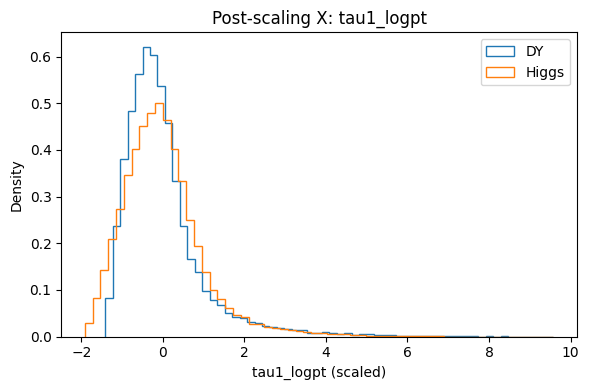

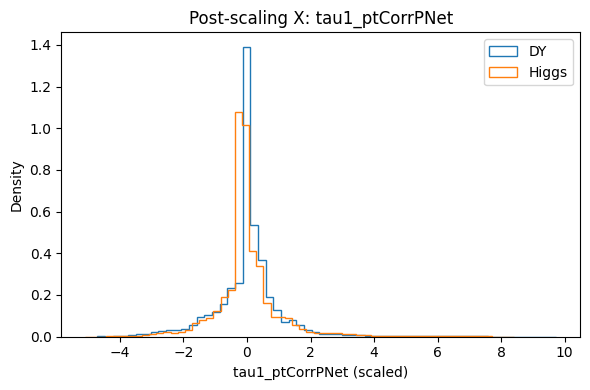

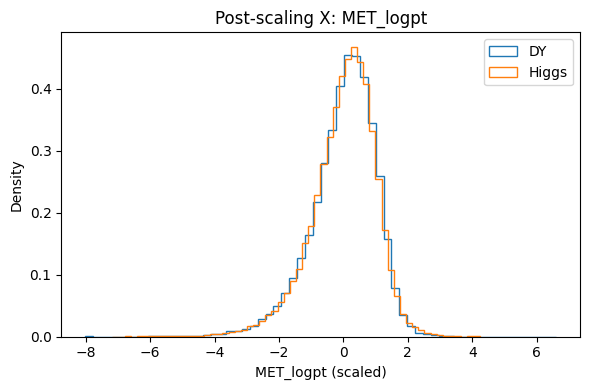

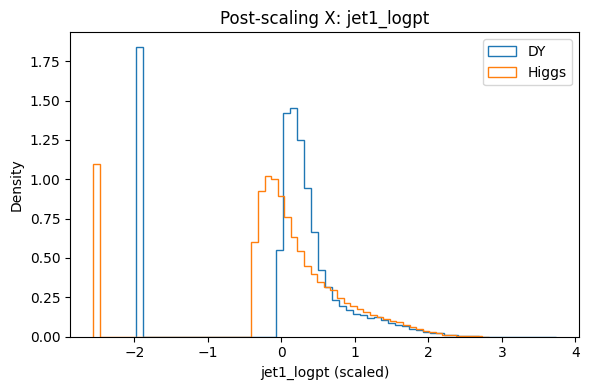

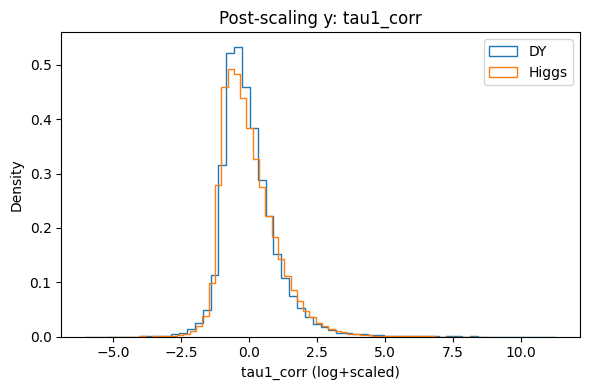

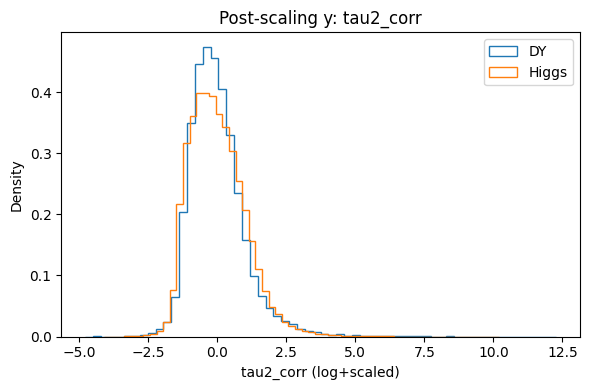

[Epoch    1] train=1.8894e+00 | val=1.7775e+00
[Epoch   10] train=1.2226e+00 | val=1.2429e+00
[Epoch   20] train=1.1340e+00 | val=1.1320e+00
[Epoch   30] train=1.0501e+00 | val=1.0673e+00
[Epoch   40] train=1.0261e+00 | val=1.0485e+00
[Epoch   50] train=1.0114e+00 | val=1.0373e+00
[Epoch   60] train=9.9775e-01 | val=1.0148e+00
[Epoch   70] train=9.9284e-01 | val=1.0217e+00
[Epoch   80] train=9.7995e-01 | val=1.0052e+00
[Epoch   90] train=9.7453e-01 | val=9.7970e-01
[Epoch  100] train=9.6751e-01 | val=9.8117e-01
[Epoch  110] train=9.5549e-01 | val=9.6119e-01
[Epoch  120] train=9.5276e-01 | val=9.7057e-01
[Epoch  130] train=9.4325e-01 | val=9.6327e-01
[Epoch  140] train=9.4116e-01 | val=9.7068e-01
[Epoch  150] train=9.3481e-01 | val=9.5241e-01
[Epoch  160] train=9.3024e-01 | val=9.5396e-01
[Epoch  170] train=9.2712e-01 | val=9.6466e-01
[Epoch  180] train=9.1940e-01 | val=9.3518e-01
[Epoch  190] train=9.0466e-01 | val=9.2087e-01
[Epoch  200] train=8.8833e-01 | val=9.1869e-01
[Epoch  210] 

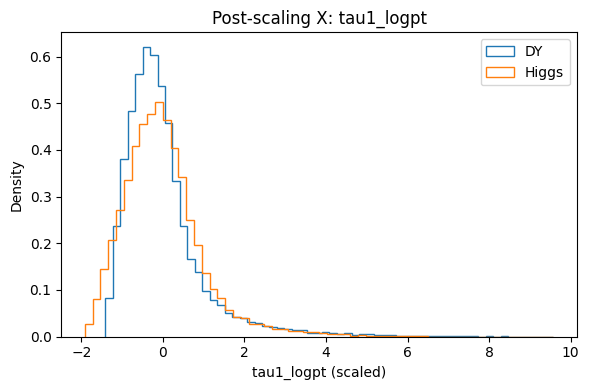

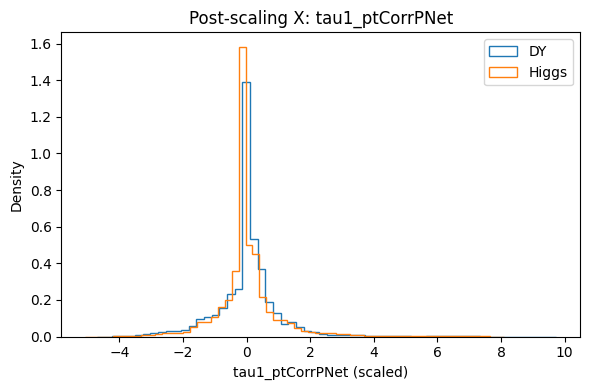

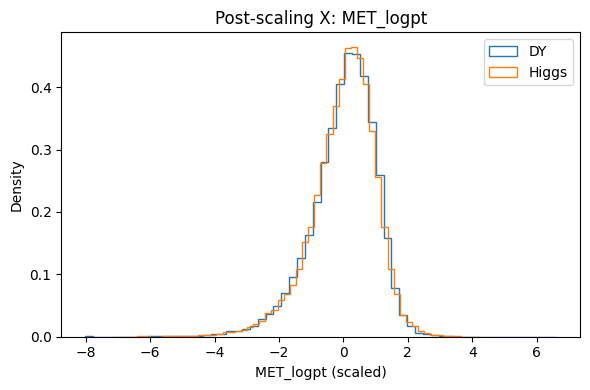

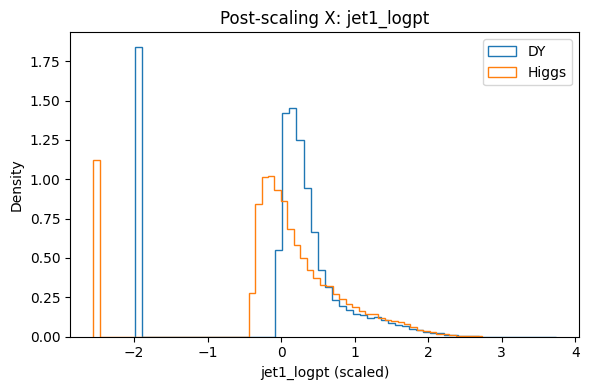

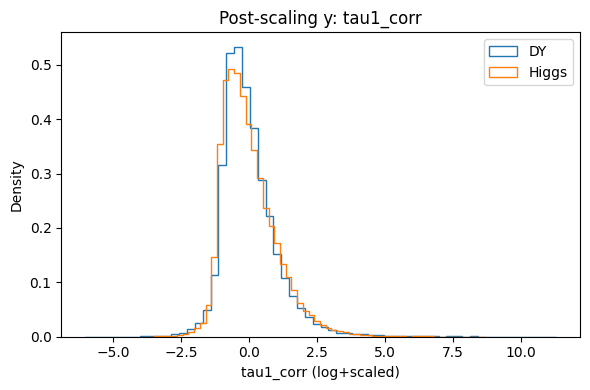

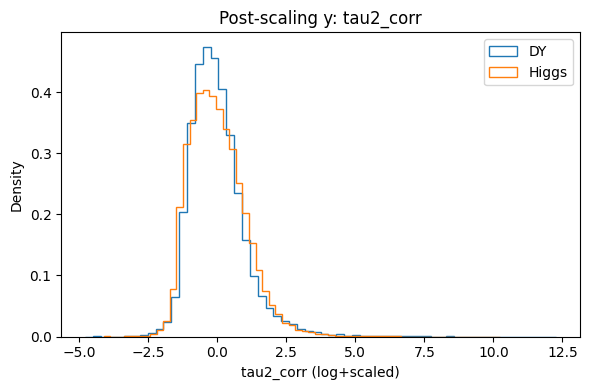

[Epoch    1] train=1.9623e+00 | val=1.8973e+00
[Epoch   10] train=1.3698e+00 | val=1.3450e+00
[Epoch   20] train=1.2368e+00 | val=1.2419e+00
[Epoch   30] train=1.2093e+00 | val=1.1974e+00
[Epoch   40] train=1.1772e+00 | val=1.1748e+00
[Epoch   50] train=1.1193e+00 | val=1.0911e+00
[Epoch   60] train=1.0887e+00 | val=1.0636e+00
[Epoch   70] train=1.0735e+00 | val=1.0534e+00
[Epoch   80] train=1.0611e+00 | val=1.0578e+00
[Epoch   90] train=1.0619e+00 | val=1.0416e+00
[Epoch  100] train=1.0479e+00 | val=1.0397e+00
[Epoch  110] train=1.0440e+00 | val=1.0120e+00
[Epoch  120] train=1.0426e+00 | val=1.0224e+00
[Epoch  130] train=1.0260e+00 | val=1.0080e+00
Early stopping at epoch 136 (best epoch=116, best val=9.9612e-01)
BALANCED test loss: 1.0073765052689447


In [109]:
# NEW 
# 1) unisco DY + H
df_all = pd.concat([df_DY_event, df_H_event], axis=0).reset_index(drop=True)

features_ctrl = [
    "tau1_logpt",
    "tau1_ptCorrPNet",
    "MET_logpt",
    "jet1_logpt",
]

y_indices_to_plot = (0, 1)


# 2) train UNBALANCED
res_unbalanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
    log_test_each_epoch=False,
    print_every=10,
    make_scaling_control_plots=True,     # <-- IMPORTANTE: fa i plot di controllo
    features_to_plot=features_ctrl,      # <-- quali X plottare
    y_indices_to_plot=(0, 1),            # <-- 2 correzioni tau1/tau2
)

print("UNBALANCED test loss:", res_unbalanced["test_loss"])

# 3) train BALANCED (downsample SOLO sul train, dentro la funzione)
res_balanced = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=True,
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
    log_test_each_epoch=False,
    print_every=10,
    make_scaling_control_plots=True,     # <-- stessi control plot anche qui
    features_to_plot=features_ctrl,
    y_indices_to_plot=(0, 1),
)

print("BALANCED test loss:", res_balanced["test_loss"])


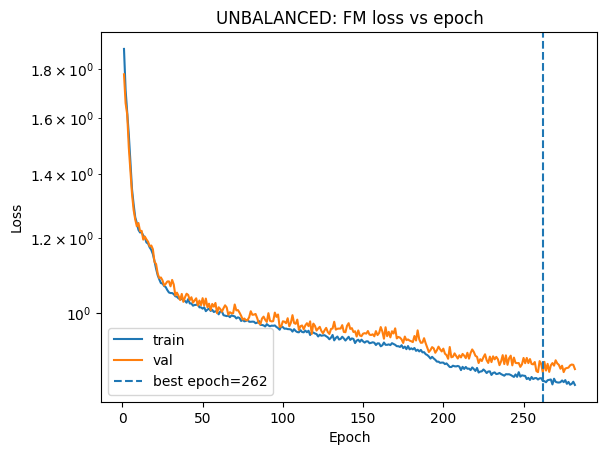

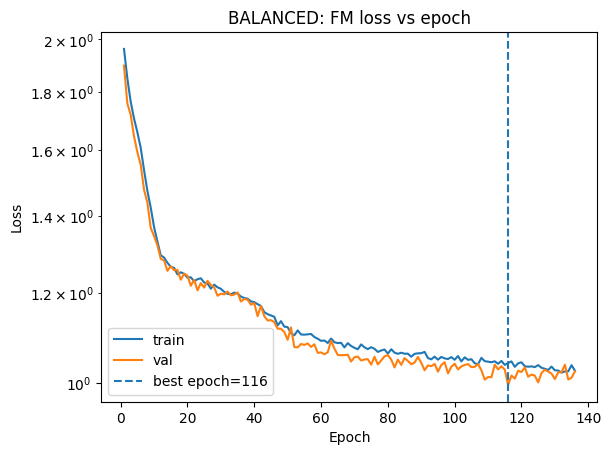

In [110]:
import numpy as np
import matplotlib.pyplot as plt

def plot_history(res, title=""):
    hist = res["history"]
    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="train")
    plt.plot(epochs, hist["val_loss"], label="val")

    if "test_loss" in hist:
        plt.plot(epochs, hist["test_loss"], label="test")

    be = res.get("best_epoch", None)
    if be is not None:
        plt.axvline(be, linestyle="--", label=f"best epoch={be}")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")  # facoltativo
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(res_unbalanced, "UNBALANCED: FM loss vs epoch")
plot_history(res_balanced,   "BALANCED: FM loss vs epoch")


In [111]:
# NEW

def plot_pre_post_scaling_2x2(
    df_train,
    train_cols,
    scalers,
    class_col="class",
    log_y=True,
    bins=60,
):
    """
    2x2 control plot:
      Row 1: pre-scaling (DY vs Higgs)
      Row 2: post-scaling (DY vs Higgs)
      Col 1: tau1_logpt
      Col 2: tau1_ptCorrPNet
    """

    vars_to_plot = ["tau1_logpt", "tau1_ptCorrPNet"]

    df_dy = df_train[df_train[class_col] == 0]
    df_h  = df_train[df_train[class_col] == 1]

    xsc_dy = scalers["DY"]["x"]
    xsc_h  = scalers["Higgs"]["x"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey="row")

    for j, var in enumerate(vars_to_plot):
        idx = train_cols.index(var)

        # ------------------
        # PRE-SCALING
        # ------------------
        x_dy_pre = df_dy[var].to_numpy()
        x_h_pre  = df_h[var].to_numpy()

        axes[0, j].hist(
            x_dy_pre, bins=bins, density=True, histtype="step", label="DY"
        )
        axes[0, j].hist(
            x_h_pre, bins=bins, density=True, histtype="step", label="Higgs"
        )
        axes[0, j].set_title(f"{var} (pre-scaling)")
        axes[0, j].set_xlabel(var)

        # ------------------
        # POST-SCALING
        # ------------------
        X_dy_scaled = xsc_dy.transform(df_dy[train_cols].to_numpy())[:, idx]
        X_h_scaled  = xsc_h.transform(df_h[train_cols].to_numpy())[:, idx]

        axes[1, j].hist(
            X_dy_scaled, bins=bins, density=True, histtype="step", label="DY"
        )
        axes[1, j].hist(
            X_h_scaled, bins=bins, density=True, histtype="step", label="Higgs"
        )
        axes[1, j].set_title(f"{var} (post-scaling)")
        axes[1, j].set_xlabel(f"{var} (scaled)")

    axes[0, 0].set_ylabel("Density")
    axes[1, 0].set_ylabel("Density")
    axes[0, 0].legend()

    plt.suptitle("Pre- vs Post-scaling control (TRAIN, DY vs Higgs)", fontsize=14)
    plt.tight_layout()
    plt.show()


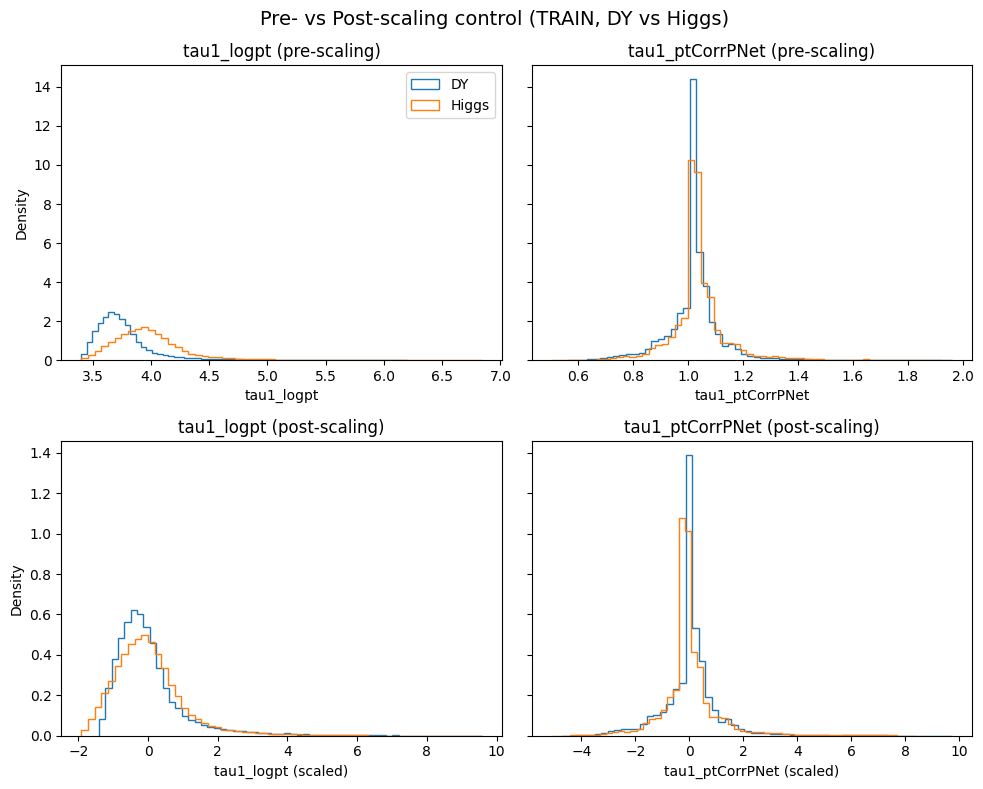

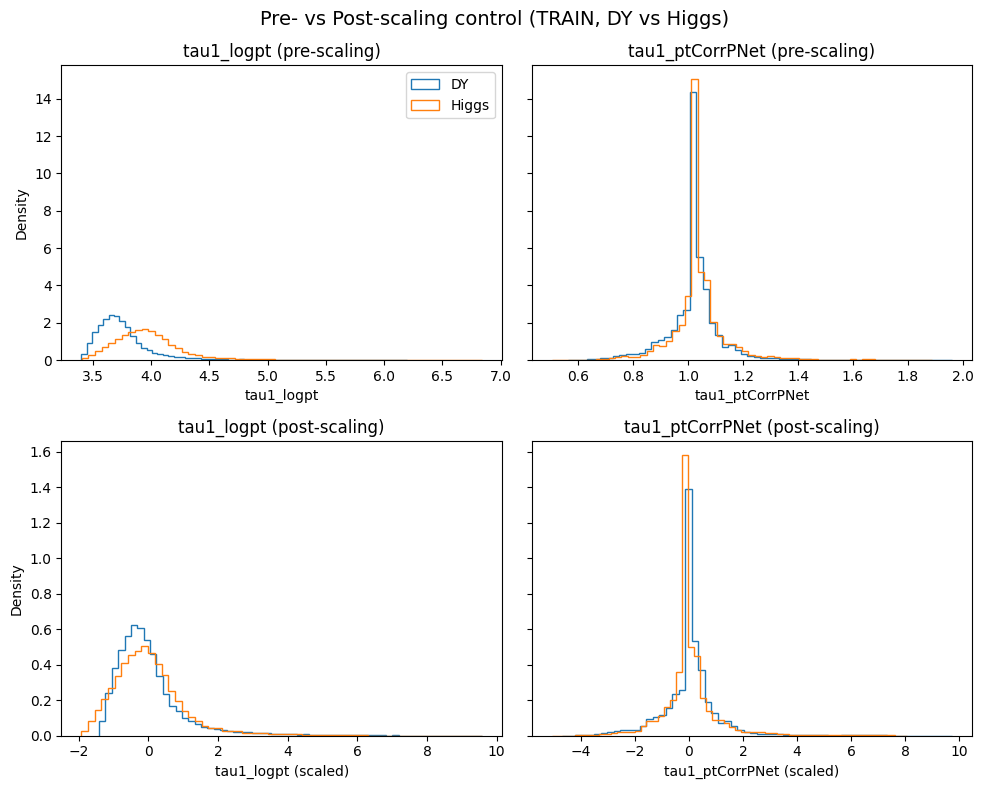

In [112]:
plot_pre_post_scaling_2x2(
    df_train=res_unbalanced["df_splits"][0],
    train_cols=train_cols,
    scalers=res_unbalanced["scalers"],
)


plot_pre_post_scaling_2x2(
    df_train=res_balanced["df_splits"][0],
    train_cols=train_cols,
    scalers=res_balanced["scalers"],
)


In [113]:
# NEW
@torch.no_grad()
def predict_tau_corr(df, res, train_cols, y_cols, n_steps=60, class_col="class"):
    model   = res["model"]
    device  = res["device"]
    scalers = res["scalers"]          # <- NEW
    log_y   = res["log_y"]

    out = df.copy()
    out["tau1_corr_pred"] = np.nan
    out["tau2_corr_pred"] = np.nan

    # helper: run one block with given scalers
    def _predict_block(df_block, xsc, ysc):
        X = xsc.transform(df_block[train_cols].to_numpy())
        X = torch.tensor(X, dtype=torch.float32, device=device)

        y_hat_s = sample_y(model, X, n_steps=n_steps, device=device)  # scaled (and maybe log)
        y_hat   = ysc.inverse_transform(y_hat_s.cpu().numpy())

        if log_y:
            y_hat = np.exp(y_hat)

        return y_hat

    # DY block
    m_dy = (out[class_col] == 0)
    if m_dy.any():
        yhat_dy = _predict_block(
            out.loc[m_dy],
            scalers["DY"]["x"],
            scalers["DY"]["y"]
        )
        out.loc[m_dy, "tau1_corr_pred"] = yhat_dy[:, 0]
        out.loc[m_dy, "tau2_corr_pred"] = yhat_dy[:, 1]

    # Higgs block
    m_h = (out[class_col] == 1)
    if m_h.any():
        yhat_h = _predict_block(
            out.loc[m_h],
            scalers["Higgs"]["x"],
            scalers["Higgs"]["y"]
        )
        out.loc[m_h, "tau1_corr_pred"] = yhat_h[:, 0]
        out.loc[m_h, "tau2_corr_pred"] = yhat_h[:, 1]

    return out



In [125]:
def pt_eta_phi_m_to_p4(pt, eta, phi, m):
    """
    Arrays -> (E, px, py, pz)
    """
    pt  = np.asarray(pt)
    eta = np.asarray(eta)
    phi = np.asarray(phi)
    m   = np.asarray(m)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    p2 = px**2 + py**2 + pz**2
    E  = np.sqrt(np.maximum(p2 + m**2, 0.0))
    return E, px, py, pz

def inv_mass_two_objects(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1, px1, py1, pz1 = pt_eta_phi_m_to_p4(pt1, eta1, phi1, m1)
    E2, px2, py2, pz2 = pt_eta_phi_m_to_p4(pt2, eta2, phi2, m2)

    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2_tot = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2_tot, 0.0))


In [115]:
# --- su quale insieme fare i plot ---
# 1. tutto df_all: 
# df_plot = df_all.copy()

# 2. plot solo test set (per evitare bias):
df_train_u, df_val_u, df_test_u = res_unbalanced["df_splits"]
df_plot = df_test_u.copy()

# 1) predizioni UNBALANCED
df_pred_u = predict_tau_corr(df_plot, res_unbalanced, train_cols, y_cols, n_steps=60)
df_plot["tau1_corr_pred_unbal"] = df_pred_u["tau1_corr_pred"].values
df_plot["tau2_corr_pred_unbal"] = df_pred_u["tau2_corr_pred"].values

# 2) predizioni BALANCED
df_pred_b = predict_tau_corr(df_plot, res_balanced, train_cols, y_cols, n_steps=60)
df_plot["tau1_corr_pred_bal"] = df_pred_b["tau1_corr_pred"].values
df_plot["tau2_corr_pred_bal"] = df_pred_b["tau2_corr_pred"].values

# 3) pT corretti
df_plot["tau1_pt_FM_unbal"] = df_plot["tau1_pt_reco_corrPNet"] * df_plot["tau1_corr_pred_unbal"]
df_plot["tau2_pt_FM_unbal"] = df_plot["tau2_pt_reco_corrPNet"] * df_plot["tau2_corr_pred_unbal"]

df_plot["tau1_pt_FM_bal"] = df_plot["tau1_pt_reco_corrPNet"] * df_plot["tau1_corr_pred_bal"]
df_plot["tau2_pt_FM_bal"] = df_plot["tau2_pt_reco_corrPNet"] * df_plot["tau2_corr_pred_bal"]

# 4) masse invarianti corrette
df_plot["inv_mass_FM_unbal"] = inv_mass_two_objects(
    df_plot["tau1_pt_FM_unbal"], df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_FM_unbal"], df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)

df_plot["inv_mass_FM_bal"] = inv_mass_two_objects(
    df_plot["tau1_pt_FM_bal"], df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_FM_bal"], df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)


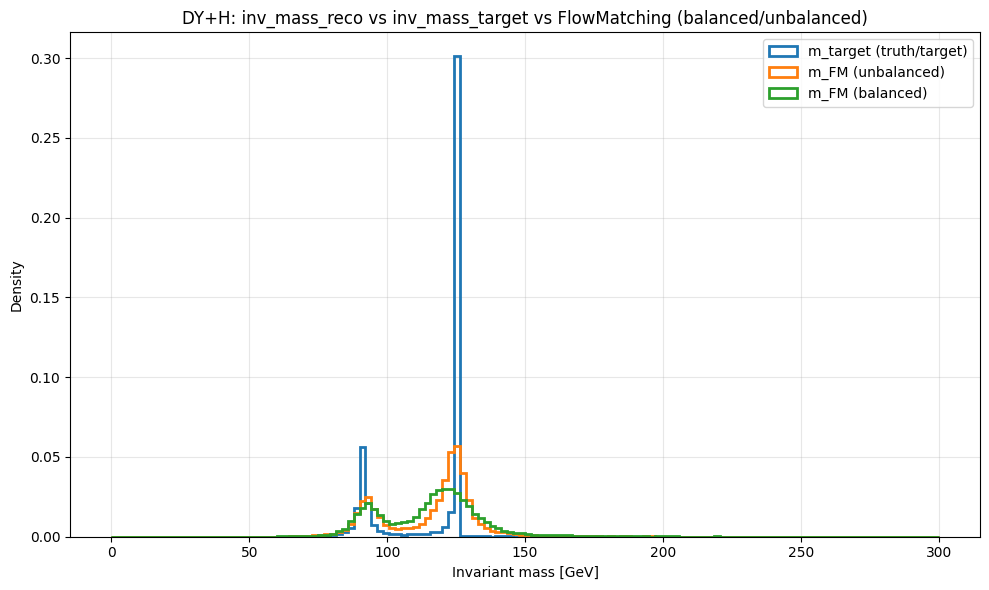

In [116]:
def plot_mass_comparison(df, bins=120, mass_range=(0, 300), title="Invariant mass comparison"):
    m_tar  = df["inv_mass_tar"].values
    m_u    = df["inv_mass_FM_unbal"].values
    m_b    = df["inv_mass_FM_bal"].values

    plt.figure(figsize=(10, 6))
    plt.hist(m_tar,  bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_target (truth/target)")
    plt.hist(m_u,    bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_FM (unbalanced)")
    plt.hist(m_b,    bins=bins, range=mass_range, histtype="step", density=True, linewidth=2, label="m_FM (balanced)")

    plt.xlabel("Invariant mass [GeV]")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_mass_comparison(
    df_plot,
    bins=140,
    mass_range=(0, 300),
    title="DY+H: inv_mass_reco vs inv_mass_target vs FlowMatching (balanced/unbalanced)"
)


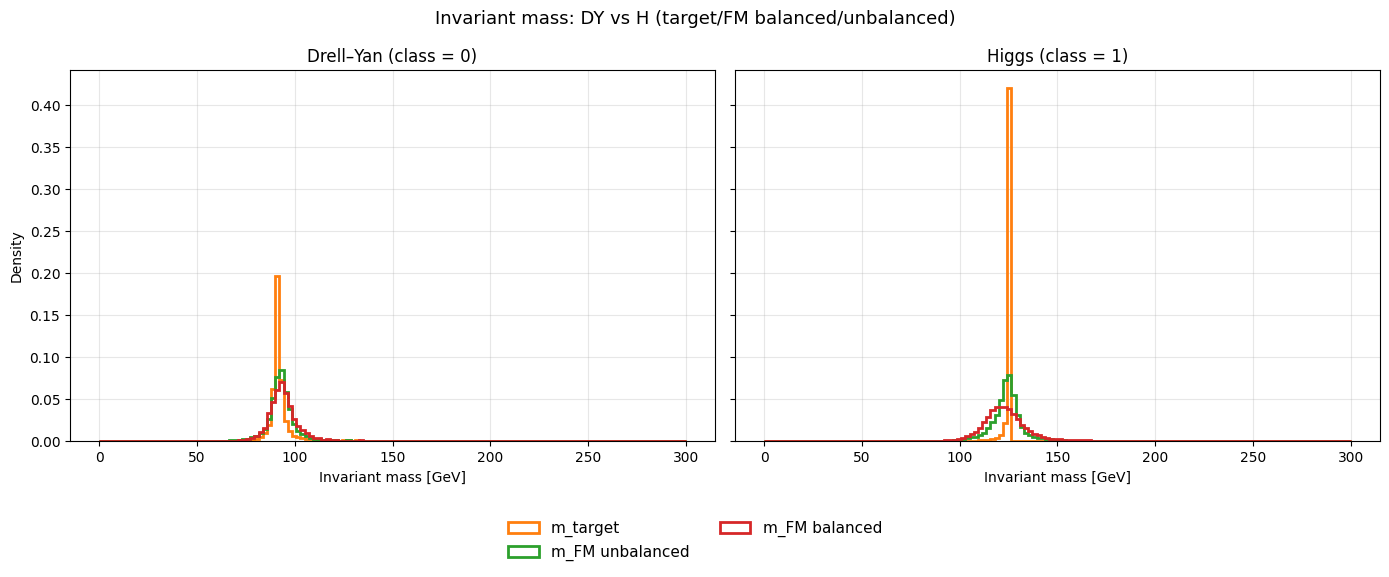

In [126]:
# NEW
def plot_mass_comparison_by_class(
    df,
    bins=140,
    mass_range=(0, 300),
    class_col="class",
    title="Invariant mass: DY vs H (target/FM balanced/unbalanced)"
):
    df_dy = df[df[class_col] == 0]
    df_h  = df[df[class_col] == 1]

    def get_arrays(d):
        return (
            d["inv_mass_tar"].values,
            d["inv_mass_FM_unbal"].values,
            d["inv_mass_FM_bal"].values,
        )

    m_tar_dy, m_u_dy, m_b_dy = get_arrays(df_dy)
    m_tar_h,  m_u_h,  m_b_h  = get_arrays(df_h)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    curves = [
        ("m_reco",           "C0"),
        ("m_target",         "C1"),
        ("m_FM unbalanced",  "C2"),
        ("m_FM balanced",    "C3"),
    ]

    # --- DY ---

    axes[0].hist(m_tar_dy,  bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[1][0], color=curves[1][1])
    axes[0].hist(m_u_dy,    bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[2][0], color=curves[2][1])
    axes[0].hist(m_b_dy,    bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[3][0], color=curves[3][1])

    axes[0].set_title("Drell–Yan (class = 0)")
    axes[0].set_xlabel("Invariant mass [GeV]")
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)

    # --- Higgs (stesse label+colori) ---
 
    axes[1].hist(m_tar_h,  bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[1][0], color=curves[1][1])
    axes[1].hist(m_u_h,    bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[2][0], color=curves[2][1])
    axes[1].hist(m_b_h,    bins=bins, range=mass_range, histtype="step", density=True, lw=2,
                 label=curves[3][0], color=curves[3][1])

    axes[1].set_title("Higgs (class = 1)")
    axes[1].set_xlabel("Invariant mass [GeV]")
    axes[1].grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=11,
               bbox_to_anchor=(0.5, -0.15))

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_mass_comparison_by_class(df_plot, bins=140, mass_range=(0, 300))

In [118]:
# NEW
# Quantitativamente :
# S/B 

# Definisco due finestre separate per DY e H (3σ troppo grande!)
DY_WIN = (70.0, 100.0)
H_WIN  = (110.0, 140.0)

def count_in_window(x, lo, hi):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    return int(np.sum((x >= lo) & (x <= hi)))

def metrics_fixed_windows(df, mass_col, class_col="class",
                          dy_win=DY_WIN, h_win=H_WIN):
    """
    Metriche con finestre fisse:
      - conteggi DY/H nelle rispettive finestre
      - S/B nella finestra Higgs
    """
    m_dy = df.loc[df[class_col] == 0, mass_col].to_numpy()
    m_h  = df.loc[df[class_col] == 1, mass_col].to_numpy()
    m_all = df[mass_col].to_numpy()

    # counts in DY window
    dy_lo, dy_hi = dy_win
    N_DY_in_DYwin = count_in_window(m_dy, dy_lo, dy_hi)
    N_H_in_DYwin  = count_in_window(m_h,  dy_lo, dy_hi)
    N_all_in_DYwin = N_DY_in_DYwin + N_H_in_DYwin
    DY_purity = (N_DY_in_DYwin / N_all_in_DYwin) if N_all_in_DYwin > 0 else np.nan

    # counts in Higgs window
    h_lo, h_hi = h_win
    N_H_in_Hwin  = count_in_window(m_h,  h_lo, h_hi)
    N_DY_in_Hwin = count_in_window(m_dy, h_lo, h_hi)
    N_all_in_Hwin = N_H_in_Hwin + N_DY_in_Hwin
    H_purity = (N_H_in_Hwin / N_all_in_Hwin) if N_all_in_Hwin > 0 else np.nan

    # S/B around Higgs peak (fixed window)
    S = N_H_in_Hwin
    B = N_DY_in_Hwin
    S_over_B = (S / B) if B > 0 else np.inf

    return {
        "mass_col": mass_col,

        # DY window
        "DYwin": (dy_lo, dy_hi),
        "N_DY_in_DYwin": N_DY_in_DYwin,
        "N_H_in_DYwin": N_H_in_DYwin,
        "DY_purity": DY_purity,

        # Higgs window
        "Hwin": (h_lo, h_hi),
        "N_H_in_Hwin": N_H_in_Hwin,
        "N_DY_in_Hwin": N_DY_in_Hwin,
        "H_purity": H_purity,

        # Higgs S/B (in Higgs window)
        "S_over_B_Hwin": S_over_B,
        "S_Hwin": S,
        "B_Hwin": B,
    }

In [119]:
for col in ["inv_mass_reco", "inv_mass_FM_unbal", "inv_mass_FM_bal"]:
    print(metrics_fixed_windows(df_plot, col))

{'mass_col': 'inv_mass_reco', 'DYwin': (70.0, 100.0), 'N_DY_in_DYwin': 3783, 'N_H_in_DYwin': 8210, 'DY_purity': 0.31543400316851494, 'Hwin': (110.0, 140.0), 'N_H_in_Hwin': 1425, 'N_DY_in_Hwin': 85, 'H_purity': 0.9437086092715232, 'S_over_B_Hwin': 16.764705882352942, 'S_Hwin': 1425, 'B_Hwin': 85}
{'mass_col': 'inv_mass_FM_unbal', 'DYwin': (70.0, 100.0), 'N_DY_in_DYwin': 4351, 'N_H_in_DYwin': 200, 'DY_purity': 0.9560536145902, 'Hwin': (110.0, 140.0), 'N_H_in_Hwin': 11398, 'N_DY_in_Hwin': 186, 'H_purity': 0.9839433701657458, 'S_over_B_Hwin': 61.27956989247312, 'S_Hwin': 11398, 'B_Hwin': 186}
{'mass_col': 'inv_mass_FM_bal', 'DYwin': (70.0, 100.0), 'N_DY_in_DYwin': 4098, 'N_H_in_DYwin': 247, 'DY_purity': 0.9431530494821634, 'Hwin': (110.0, 140.0), 'N_H_in_Hwin': 10441, 'N_DY_in_Hwin': 214, 'H_purity': 0.9799155326137964, 'S_over_B_Hwin': 48.78971962616822, 'S_Hwin': 10441, 'B_Hwin': 214}


In [120]:
# NEW
def build_metrics_table(
    df,
    mass_cols,
    class_col="class",
    dy_win=(70, 100),
    h_win=(110, 140),
):
    rows = []

    for col in mass_cols:
        res = metrics_fixed_windows(
            df,
            mass_col=col,
            class_col=class_col,
            dy_win=dy_win,
            h_win=h_win,
        )

        rows.append({
            "mass": col,

            # DY window
            "DY window [GeV]": f"{dy_win[0]}–{dy_win[1]}",
            "N_DY (DYwin)": res["N_DY_in_DYwin"],
            "N_H (DYwin)":  res["N_H_in_DYwin"],

            # Higgs window
            "H window [GeV]": f"{h_win[0]}–{h_win[1]}",
            "N_H (Hwin)":  res["N_H_in_Hwin"],
            "N_DY (Hwin)": res["N_DY_in_Hwin"],

            # Higgs S/B
            "S/B (Hwin)": res["S_over_B_Hwin"],
        })

    df_out = pd.DataFrame(rows)

    # formatting
    df_out["S/B (Hwin)"] = (
        df_out["S/B (Hwin)"]
        .replace(np.inf, np.nan)
        .astype(float)
        .round(3)
    )

    return df_out

mass_cols = [
    "inv_mass_FM_unbal",
    "inv_mass_FM_bal",
]

metrics_df = build_metrics_table(
    df_plot,
    mass_cols,
    class_col="class",
)

metrics_df


,mass,DY window [GeV],N_DY (DYwin),N_H (DYwin),H window [GeV],N_H (Hwin),N_DY (Hwin),S/B (Hwin)
0,inv_mass_FM_unbal,70–100,4351,200,110–140,11398,186,61.28
1,inv_mass_FM_bal,70–100,4098,247,110–140,10441,214,48.79


In [121]:
# NEW: KL divergence (H || DY)

def compute_KL_divergence(
    df,
    mass_col,
    class_col="class",
    bins=120,
    mass_range=(70, 140),   # <-- regione fisicamente rilevante
    eps=1e-12
):
    """
    Compute KL(H || DY) between Higgs and DY invariant-mass distributions.
    """
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values

    p_h, bin_edges = np.histogram(
        m_h, bins=bins, range=mass_range, density=True
    )
    p_dy, _ = np.histogram(
        m_dy, bins=bins, range=mass_range, density=True
    )

    # avoid log(0)
    p_h  = p_h  + eps
    p_dy = p_dy + eps

    kl = np.sum(p_h * np.log(p_h / p_dy))
    return kl


# ------------------------------------------------------------
# Compute KL for FM models (no reco)
# ------------------------------------------------------------
kl_unbal = compute_KL_divergence(df_plot, "inv_mass_FM_unbal")
kl_bal   = compute_KL_divergence(df_plot, "inv_mass_FM_bal")


kl_df = pd.DataFrame({
    "mass": ["inv_mass_FM_unbal", "inv_mass_FM_bal"],
    "KL(H || DY) [70–140 GeV]": [kl_unbal, kl_bal],
})

kl_df["KL(H || DY) [70–140 GeV]"] = kl_df["KL(H || DY) [70–140 GeV]"].round(3)

kl_df



,mass,KL(H || DY) [70–140 GeV]
0,inv_mass_FM_unbal,9.891
1,inv_mass_FM_bal,5.419


In [122]:
# NEW: Earth Mover's Distance (Wasserstein-1) on invariant mass

from scipy.stats import wasserstein_distance

def compute_EMD(
    df,
    mass_col,
    class_col="class",
    mass_range=(70, 140),
):
    """
    Compute EMD (Wasserstein-1) between Higgs and DY invariant-mass distributions
    in a fixed mass range.
    """
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values

    # restrict to the relevant mass window
    m_h  = m_h[(m_h >= mass_range[0]) & (m_h <= mass_range[1])]
    m_dy = m_dy[(m_dy >= mass_range[0]) & (m_dy <= mass_range[1])]

    return wasserstein_distance(m_h, m_dy)


# ------------------------------------------------------------
# Compute EMD for FM models (no reco)
# ------------------------------------------------------------
emd_unbal = compute_EMD(df_plot, "inv_mass_FM_unbal")
emd_bal   = compute_EMD(df_plot, "inv_mass_FM_bal")

emd_df = pd.DataFrame({
    "mass": ["inv_mass_FM_unbal", "inv_mass_FM_bal"],
    "EMD(H, DY) [70–140 GeV]": [emd_unbal, emd_bal],
})

emd_df["EMD(H, DY) [70–140 GeV]"] = emd_df["EMD(H, DY) [70–140 GeV]"].round(3)

emd_df


,mass,"EMD(H, DY) [70–140 GeV]"
0,inv_mass_FM_unbal,29.235
1,inv_mass_FM_bal,26.643


In [123]:
summary_df = pd.DataFrame({
    "training": ["FM unbalanced", "FM balanced"],


    "S/B (H window 110–140)": [
        metrics_df.loc[metrics_df["mass"] == "inv_mass_FM_unbal", "S/B (Hwin)"].values[0],
        metrics_df.loc[metrics_df["mass"] == "inv_mass_FM_bal",   "S/B (Hwin)"].values[0],
    ],

    "KL(H || DY) [70–140]": [
        kl_unbal,
        kl_bal,
    ],

    "EMD(H, DY) [GeV]": [
        emd_unbal,
        emd_bal,
    ],
})

summary_df["S/B (H window 110–140)"] = summary_df["S/B (H window 110–140)"].round(2)
summary_df["KL(H || DY) [70–140]"]   = summary_df["KL(H || DY) [70–140]"].round(3)
summary_df["EMD(H, DY) [GeV]"]       = summary_df["EMD(H, DY) [GeV]"].round(3)

summary_df

,training,S/B (H window 110–140),KL(H || DY) [70–140],"EMD(H, DY) [GeV]"
0,FM unbalanced,61.28,9.891,29.235
1,FM balanced,48.79,5.419,26.643


- To sum up:
 1. The unbalanced training provides the best signal-to-background performance and maximizes the separation between Higgs and Drell–Yan in the signal region
 2. The balanced training yields a smaller Earth Mover's Distance, indicating a more regular and less aggressive transformation


-> Unbalanced model

# 2. Cut on Tails (m_tar)

In [53]:
# NEW: 
# class-dependent tail cuts on inv_mass_tar
dy_win = (70.0, 100.0)
h_win  = (110.0, 140.0)

# split by class
df_dy = df_all[df_all["class"] == 0]
df_h  = df_all[df_all["class"] == 1]

# apply class-specific cuts (on target mass)
df_dy_cut = df_dy[
    (df_dy["inv_mass_tar"] >= dy_win[0]) &
    (df_dy["inv_mass_tar"] <= dy_win[1])
].copy()

df_h_cut = df_h[
    (df_h["inv_mass_tar"] >= h_win[0]) &
    (df_h["inv_mass_tar"] <= h_win[1])
].copy()

# merge + shuffle
df_all_cut = (
    pd.concat([df_dy_cut, df_h_cut], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

# sanity prints
print("=== Tail cut summary (inv_mass_tar) ===")
print(f"Pre-cut total:  {len(df_all)}")
print(f"  DY pre-cut:   {len(df_dy)}")
print(f"  H  pre-cut:   {len(df_h)}")
print(f"Post-cut total: {len(df_all_cut)}")
print(f"  DY post-cut:  {len(df_dy_cut)}  (kept {len(df_dy_cut)/max(len(df_dy),1):.3f})  window={dy_win}")
print(f"  H  post-cut:  {len(df_h_cut)}   (kept {len(df_h_cut)/max(len(df_h),1):.3f})   window={h_win}")


=== Tail cut summary (inv_mass_tar) ===
Pre-cut total:  179459
  DY pre-cut:   51425
  H  pre-cut:   128034
Post-cut total: 172337
  DY post-cut:  45542  (kept 0.886)  window=(70.0, 100.0)
  H  post-cut:  126795   (kept 0.990)   window=(110.0, 140.0)


In [54]:
# NEW: train UNBALANCED on tail-cut sample (df_all_cut)
res_unbalanced_cut = train_conditional_flow_matching(
    df_all=df_all_cut,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,          # UNBALANCED
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
    log_test_each_epoch=False,
    print_every=10,          # <-- stampa loss ogni 10 epoche
)

print("UNBALANCED (CUT) test loss:", res_unbalanced_cut["test_loss"])
print("Best epoch (by val):", res_unbalanced_cut["best_epoch"])

Split summary
  Train:   137869  frac: {1: 0.736, 0: 0.264}
  Val  :    17234  frac: {1: 0.736, 0: 0.264}
  Test :    17234  frac: {1: 0.736, 0: 0.264}
[Epoch    1] train=1.8752e+00 | val=1.7489e+00
[Epoch   10] train=1.1767e+00 | val=1.1738e+00
[Epoch   20] train=1.0091e+00 | val=1.0285e+00
[Epoch   30] train=9.6172e-01 | val=9.8660e-01
[Epoch   40] train=9.4628e-01 | val=9.7868e-01
[Epoch   50] train=9.3738e-01 | val=9.2258e-01
[Epoch   60] train=9.1816e-01 | val=9.1815e-01
[Epoch   70] train=9.1874e-01 | val=9.1465e-01
[Epoch   80] train=8.9491e-01 | val=9.0288e-01
[Epoch   90] train=8.9875e-01 | val=8.9984e-01
[Epoch  100] train=8.9841e-01 | val=9.0913e-01
[Epoch  110] train=8.8362e-01 | val=9.0032e-01
Early stopping at epoch 112 (best epoch=92, best val=8.9691e-01)
UNBALANCED (CUT) test loss: 0.9169105357593961
Best epoch (by val): 92


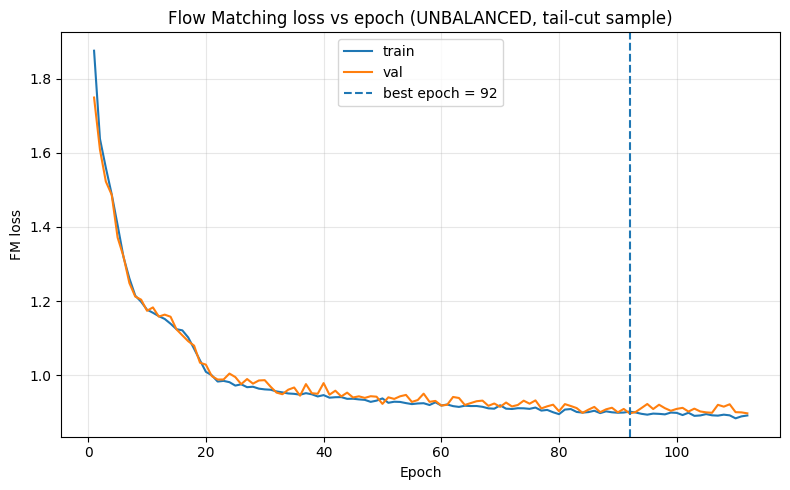

In [55]:
def plot_training_history(res, title="Training history"):
    hist = res["history"]
    train_loss = np.array(hist["train_loss"], dtype=float)
    val_loss   = np.array(hist["val_loss"], dtype=float)

    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="train")
    plt.plot(epochs, val_loss, label="val")

    best_epoch = res.get("best_epoch", None)
    if best_epoch is not None:
        plt.axvline(best_epoch, linestyle="--", linewidth=1.5, label=f"best epoch = {best_epoch}")

    plt.xlabel("Epoch")
    plt.ylabel("FM loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(
    res_unbalanced_cut,
    title="Flow Matching loss vs epoch (UNBALANCED, tail-cut sample)"
)

In [57]:
# NEW

@torch.no_grad()
def predict_tau_corr_by_class(df, res, train_cols, y_cols, class_col="class", n_steps=60):
    model  = res["model"]
    device = res["device"]
    scalers = res["scalers"]
    log_y  = scalers.get("log_y", res.get("log_y", True))

    out = df.copy()
    out["tau1_corr_pred"] = np.nan
    out["tau2_corr_pred"] = np.nan

    for cls, key in [(0, "DY"), (1, "Higgs")]:
        mask = (out[class_col].values == cls)
        if mask.sum() == 0:
            continue

        xscaler = scalers[key]["x"]
        yscaler = scalers[key]["y"]

        X = xscaler.transform(out.loc[mask, train_cols].to_numpy())
        X = torch.tensor(X, dtype=torch.float32, device=device)

        y_hat_s = sample_y(model, X, n_steps=n_steps, device=device)  # scaled (and maybe log)
        y_hat   = yscaler.inverse_transform(y_hat_s.cpu().numpy())

        if log_y:
            y_hat = np.exp(y_hat)

        out.loc[mask, "tau1_corr_pred"] = y_hat[:, 0]
        out.loc[mask, "tau2_corr_pred"] = y_hat[:, 1]

    return out

# predizioni modello PRE-CUT (unbalanced)
df_pred_pre = predict_tau_corr_by_class(
    df_plot,
    res_unbalanced,
    train_cols,
    y_cols,
    class_col="class",
    n_steps=60
)

# predizioni modello POST-CUT (unbalanced trained on df_all_cut)
df_pred_cut = predict_tau_corr_by_class(
    df_plot,
    res_unbalanced_cut,
    train_cols,
    y_cols,
    class_col="class",
    n_steps=60
)



In [58]:
# NEW : mi assicuro che i df siano allineati riga per riga con df_plot
# --- PRE-CUT: pT corretti e massa ---
tau1_pt_pre = df_plot["tau1_pt_reco_corrPNet"].values * df_pred_pre["tau1_corr_pred"].values
tau2_pt_pre = df_plot["tau2_pt_reco_corrPNet"].values * df_pred_pre["tau2_corr_pred"].values

df_plot["inv_mass_FM_pre"] = inv_mass_two_objects(
    tau1_pt_pre, df_plot["tau1_eta"].values, df_plot["tau1_phi"].values, df_plot["tau1_mass"].values,
    tau2_pt_pre, df_plot["tau2_eta"].values, df_plot["tau2_phi"].values, df_plot["tau2_mass"].values,
)

# --- POST-CUT: pT corretti e massa ---
tau1_pt_cut = df_plot["tau1_pt_reco_corrPNet"].values * df_pred_cut["tau1_corr_pred"].values
tau2_pt_cut = df_plot["tau2_pt_reco_corrPNet"].values * df_pred_cut["tau2_corr_pred"].values

df_plot["inv_mass_FM_cut"] = inv_mass_two_objects(
    tau1_pt_cut, df_plot["tau1_eta"].values, df_plot["tau1_phi"].values, df_plot["tau1_mass"].values,
    tau2_pt_cut, df_plot["tau2_eta"].values, df_plot["tau2_phi"].values, df_plot["tau2_mass"].values,
)


In [59]:
# check :
print("NaN corr pre :", df_pred_pre[["tau1_corr_pred","tau2_corr_pred"]].isna().sum().to_dict())
print("NaN corr cut :", df_pred_cut[["tau1_corr_pred","tau2_corr_pred"]].isna().sum().to_dict())


NaN corr pre : {'tau1_corr_pred': 0, 'tau2_corr_pred': 0}
NaN corr cut : {'tau1_corr_pred': 0, 'tau2_corr_pred': 0}


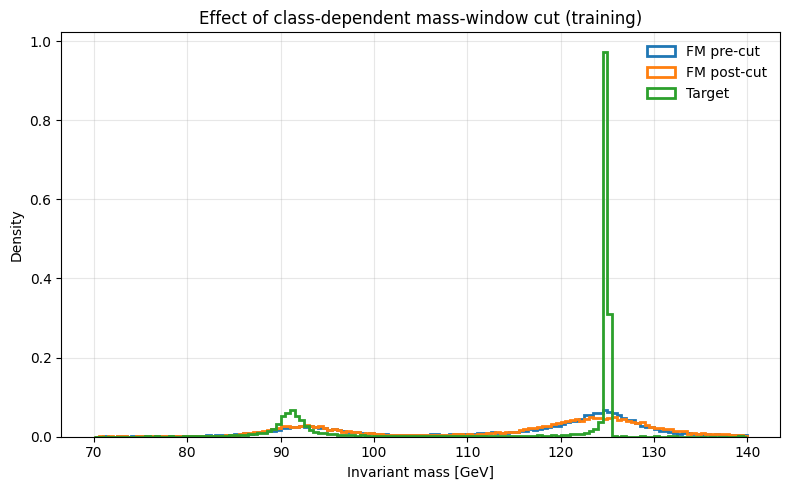

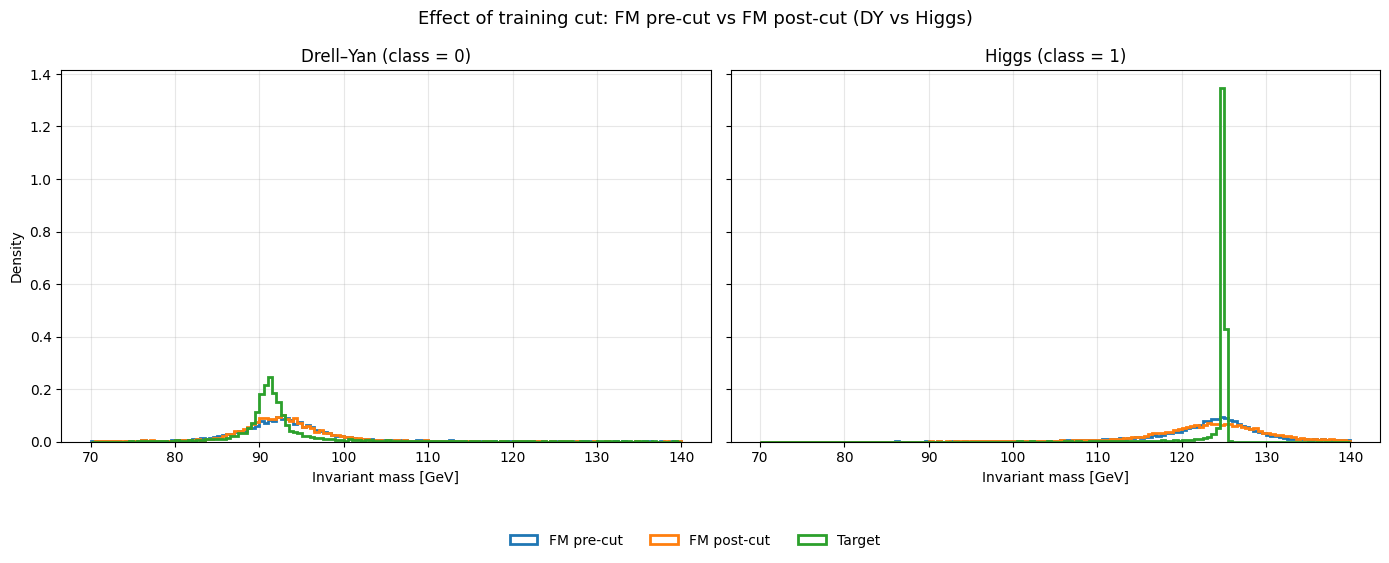

In [62]:
bins = 140
mass_range = (70, 140)   # <-- vedo l'effetto del cut
# mass_range = (0, 300)  # <-- se voglio vedere anche le code

plt.figure(figsize=(8,5))
plt.hist(df_plot["inv_mass_FM_pre"].values, bins=bins, range=mass_range,
         histtype="step", density=True, lw=2, label="FM pre-cut")
plt.hist(df_plot["inv_mass_FM_cut"].values, bins=bins, range=mass_range,
         histtype="step", density=True, lw=2, label="FM post-cut")
plt.hist(df_plot["inv_mass_tar"].values, bins=bins, range=mass_range,
         histtype="step", density=True, lw=2, label="Target")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.title("Effect of class-dependent mass-window cut (training)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

def plot_pre_vs_cut_by_class(
    df,
    class_col="class",
    bins=140,
    mass_range=(70, 140),
    title="Pre-cut vs post-cut FM (by class)"
):
    df_dy = df[df[class_col] == 0]
    df_h  = df[df[class_col] == 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # --- DY ---
    axes[0].hist(df_dy["inv_mass_FM_pre"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2, label="FM pre-cut")
    axes[0].hist(df_dy["inv_mass_FM_cut"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2, label="FM post-cut")
    axes[0].hist(df_dy["inv_mass_tar"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2, label="Target")
    axes[0].set_title("Drell–Yan (class = 0)")
    axes[0].set_xlabel("Invariant mass [GeV]")
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)

    # --- Higgs ---
    axes[1].hist(df_h["inv_mass_FM_pre"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2)
    axes[1].hist(df_h["inv_mass_FM_cut"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2)
    axes[1].hist(df_h["inv_mass_tar"].values, bins=bins, range=mass_range,
                 histtype="step", density=True, lw=2)
    axes[1].set_title("Higgs (class = 1)")
    axes[1].set_xlabel("Invariant mass [GeV]")
    axes[1].grid(alpha=0.3)

    # legenda globale
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.12))

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_pre_vs_cut_by_class(
    df_plot,
    bins=140,
    mass_range=(70, 140),  
    title="Effect of training cut: FM pre-cut vs FM post-cut (DY vs Higgs)"
)


In [65]:
# Quantitativamente :
from scipy.stats import wasserstein_distance

# -------------------------
# Metrics helpers
# -------------------------
def compute_SB_in_fixed_windows(df, mass_col, class_col="class", h_win=(110,140)):
    """S/B computed in Higgs window: S = #H in Hwin, B = #DY in Hwin."""
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values
    low, high = h_win
    S = np.sum((m_h  >= low) & (m_h  <= high))
    B = np.sum((m_dy >= low) & (m_dy <= high))
    return np.inf if B == 0 else (S / B)

def compute_KL_divergence_hist(df, mass_col, class_col="class",
                              bins=140, mass_range=(70,140), eps=1e-12):
    """KL(H || DY) using histogram densities on a fixed range."""
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values

    p_h, _  = np.histogram(m_h,  bins=bins, range=mass_range, density=True)
    p_dy, _ = np.histogram(m_dy, bins=bins, range=mass_range, density=True)

    p_h  = p_h  + eps
    p_dy = p_dy + eps
    return float(np.sum(p_h * np.log(p_h / p_dy)))

def compute_EMD(df, mass_col, class_col="class"):
    """Earth Mover's Distance (Wasserstein-1) between H and DY (in GeV)."""
    m_h  = df[df[class_col] == 1][mass_col].values
    m_dy = df[df[class_col] == 0][mass_col].values
    return float(wasserstein_distance(m_h, m_dy))

# -------------------------
# Tabella
# -------------------------
def build_pre_post_cut_table(df, pre_col="inv_mass_FM_pre", post_col="inv_mass_FM_cut",
                             class_col="class", h_win=(110,140),
                             kl_bins=140, kl_range=(70,140)):
    rows = []
    for name, col in [("FM pre-cut", pre_col), ("FM post-cut", post_col)]:
        rows.append({
            "training": name,
            f"S/B (H window {h_win[0]}–{h_win[1]})": compute_SB_in_fixed_windows(df, col, class_col=class_col, h_win=h_win),
            f"KL(H || DY) [{kl_range[0]}–{kl_range[1]}]": compute_KL_divergence_hist(df, col, class_col=class_col,
                                                                                    bins=kl_bins, mass_range=kl_range),
            "EMD(H, DY) [GeV]": compute_EMD(df, col, class_col=class_col),
        })

    out = pd.DataFrame(rows)

    sb_col = f"S/B (H window {h_win[0]}–{h_win[1]})"
    kl_col = f"KL(H || DY) [{kl_range[0]}–{kl_range[1]}]"
    out[sb_col] = out[sb_col].replace(np.inf, np.nan).astype(float).round(3)
    out[kl_col] = out[kl_col].astype(float).round(3)
    out["EMD(H, DY) [GeV]"] = out["EMD(H, DY) [GeV]"].astype(float).round(3)

    return out

metrics_pre_post = build_pre_post_cut_table(
    df_plot,
    pre_col="inv_mass_FM_pre",
    post_col="inv_mass_FM_cut",
    class_col="class",
    h_win=(110,140),
    kl_bins=140,
    kl_range=(70,140),
)

metrics_pre_post


,training,S/B (H window 110–140),KL(H || DY) [70–140],"EMD(H, DY) [GeV]"
0,FM pre-cut,54.780,9.371,30.652
1,FM post-cut,90.913,16.335,31.360


# 3. Flat Samples + Fine Tuning

In [66]:
# --------- Apro i samples flat  ------------
VBF = np.load("VBFtoXto2Tau_M-30to300.npz")

print(VBF.files)

# check :
print("x_taus:", VBF["x_taus"].shape)
print("x_taus_gen", VBF["x_gen"].shape)
print("x_met :", VBF["x_met"].shape)
print("x_jets:", VBF["x_jets"].shape)
print("m_gen :", VBF["m_gen"].shape)

['x_taus', 'x_tauprod', 'x_met', 'x_jets', 'x_neutrinos', 'x_gen', 'm_vis', 'm_vis_ptcorr', 'm_gen', 'm_gen_pt_vis_angles', 'm_vis_ptcorr_plus_nu', 'm_tauprod_nu', 'm_vis_nu_vis', 'm_fastmtt']
x_taus: (632014, 2, 18)
x_taus_gen (632014, 2, 4)
x_met : (632014, 1, 8)
x_jets: (632014, 3, 4)
m_gen : (632014,)


In [67]:
taus = VBF["x_taus"]        # shape (N, 2, 18)
# tauprod = VBF["x_tauprod"]  # shape (N, 10, 10)
tau_gen = VBF["x_gen"]       # shape (N, 2,  4)
met = VBF["x_met"]          # shape (N, 1, 8)
jets = VBF["x_jets"]        # shape (N, 3, 4)

m_vis_ptcorr = VBF["m_vis_ptcorr"]   # (N,)    --> La uso come m_reco
m_target = VBF["m_gen"]              # (N,)
m_vis = VBF["m_vis"]                 # (N,)
m_fastmtt = VBF["m_fastmtt"]         # (N,)


tau_features = [
    "logpt", "eta", "phi", "mass", "dxy", "dz",
    "ptCorrPNet", "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi", "leadTkPtOverTauPt"
]

gen_tau_features = ["pt", "eta", "phi", "mass"]  # x_gen


import pandas as pd

N = taus.shape[0]

df = {}

# ---------- TAU 1 & TAU 2 ----------
for itau in [0, 1]:
    prefix = f"tau{itau+1}_"
    for i, feat in enumerate(tau_features):
        df[prefix + feat] = taus[:, itau, i]

# ---------- TAU GEN (TAU 1 & TAU 2) ----------
for itau in [0, 1]:
    prefix = f"gen_tau{itau+1}_"
    for i, feat in enumerate(gen_tau_features):
        df[prefix + feat] = tau_gen[:, itau, i]

# ---------- MET ----------
met_features = [
    "MET_logpt", "MET_phi", "MET_covXX", "MET_covXY",
    "MET_covYY", "MET_significance", "MET_sumEt", "MET_sumPtUnclustered"
]

for i, feat in enumerate(met_features):
    df[feat] = met[:, 0, i]

# ---------- JETS (3 jets) ----------
jet_features = ["logpt", "eta", "phi", "mass"]

for j in range(3):
    for i, feat in enumerate(jet_features):
        df[f"jet{j+1}_{feat}"] = jets[:, j, i]

# ---------- MASSE ----------
df["m_vis"]         = m_vis
df["m_vis_ptcorr"]  = m_vis_ptcorr
df["m_fastmtt"]     = m_fastmtt
df["m_gen"]         = m_target


df_flat = pd.DataFrame(df)

print(df_flat.shape)
df_flat.head()

(632014, 68)


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen
0,4.200094,1.643799,2.515137,2.949219,0.634277,5.184814,1.001953,0.999512,-1.000000,-1.0,...,-1.327881,5.281250,2.880777,1.763184,-0.800903,3.589844,24.438859,27.647144,33.020302,47.239086
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,1.614990,10.671875,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752
2,3.746890,-0.771606,2.914062,1.334961,0.001616,-0.001660,0.996582,0.883789,0.977051,1.0,...,0.796753,6.765625,3.711283,1.373779,2.641602,7.281250,61.325864,60.001639,83.316399,77.556129
3,3.882379,-1.166748,-0.862671,0.836914,-0.000545,0.000682,0.957031,0.780762,0.909668,1.0,...,2.308594,4.167969,3.327730,-2.611816,2.785645,4.589844,109.263026,97.097534,148.204529,102.891235
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,-2.422363,6.937500,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426


In [68]:
df_flat["gen_tau1_logpt"] = np.log(np.clip(tau_gen[:, 0, 0], 1e-6, None))
df_flat["gen_tau2_logpt"] = np.log(np.clip(tau_gen[:, 1, 0], 1e-6, None))

log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df_flat["tau1_logpt"] > log_pt_min) & (df_flat["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_flat))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel_flat = df_flat[mask_pt].copy()

df_sel_flat["tau1_ptreco"] = np.exp(df_sel_flat["tau1_logpt"])
df_sel_flat["tau2_ptreco"] = np.exp(df_sel_flat["tau2_logpt"])

df_sel_flat["tau1_pt_reco_corrPNet"] = df_sel_flat["tau1_ptreco"] * df_sel_flat["tau1_ptCorrPNet"]
df_sel_flat["tau2_pt_reco_corrPNet"] = df_sel_flat["tau2_ptreco"] * df_sel_flat["tau2_ptCorrPNet"]
df_sel_flat

Eventi totali: 632014
Eventi che passano pT>30 GeV (in log): 394047


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


In [69]:
# tau ID

df_sel_flat_valid = df_sel_flat[
    (df_sel_flat["tau1_rawPNetVSjet"] != -1) &
    (df_sel_flat["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_flat_valid))

# Soglia al working point 90% :
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

vals_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"].values
thresholds_tau1 = np.sort(np.unique(vals_tau1))

vals_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"].values
thresholds_tau2 = np.sort(np.unique(vals_tau2))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

# Applico le soglie event - level : 
mask_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_event  = mask_tau1 & mask_tau2

df_sel_tauID = df_sel_flat_valid[mask_event].copy()

# efficienza event-level 
eff_event = mask_event.mean() if len(df_sel_flat_valid) > 0 else float("nan")

print("Efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_event:.4f}")

df_flat_event = df_sel_tauID.copy()
df_flat_event

DY valid events = 391777
Efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8129


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,m_vis,m_vis_ptcorr,m_fastmtt,m_gen,gen_tau1_logpt,gen_tau2_logpt,tau1_ptreco,tau2_ptreco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,85.437739,93.784651,109.942673,106.047752,5.659482,4.324132,256.755389,56.138509,262.271618,66.225898
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,104.564076,127.417169,143.905762,133.224426,4.317488,3.562465,49.391065,32.726376,71.530225,33.557319
7,4.752875,-0.372742,-3.123535,1.243164,-0.006924,-0.005308,1.016602,0.999512,0.999512,-1.0,...,179.161750,182.135892,245.033875,275.803833,4.822296,4.734003,115.917106,51.630252,117.841511,52.487394
8,3.785749,-0.706299,1.264404,0.820801,0.001562,-0.005122,1.020508,0.997070,0.999512,1.0,...,58.791301,59.737181,78.706543,70.577286,4.077538,3.778491,44.068653,39.733000,44.972405,40.198621
11,4.063381,-2.416992,0.866211,0.790527,-0.000340,0.002485,1.047852,0.875488,0.941406,1.0,...,165.567559,168.653555,259.882599,269.511292,4.069027,4.497028,58.170638,33.668525,60.954193,33.339731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632009,4.799636,-1.569092,2.992188,0.139526,-0.000405,0.001151,1.018555,0.999023,0.975586,-1.0,...,66.710782,69.521614,85.153633,81.033844,5.049856,3.823192,121.466182,39.515781,123.719949,42.139876
632010,4.394889,-1.463867,-1.856689,1.301758,-0.009041,0.014961,1.169922,0.930176,0.878906,1.0,...,139.302899,143.166716,218.654175,264.772156,4.751433,5.053056,81.035625,61.770415,94.805351,55.768309
632011,4.144735,0.811768,-0.025539,0.139526,0.000309,0.001976,1.064453,0.985352,0.997559,-1.0,...,58.390797,57.425191,71.106628,74.561821,4.551242,3.901973,63.100889,46.598283,67.167939,42.184188
632012,4.284923,-1.029297,3.136719,0.895020,-0.001932,0.000072,1.020508,0.998535,0.999512,-1.0,...,117.331283,127.608025,150.473145,203.232407,5.056246,4.477337,72.596962,63.739941,74.085767,73.886045


Before cut: 318494
After cut: 49798


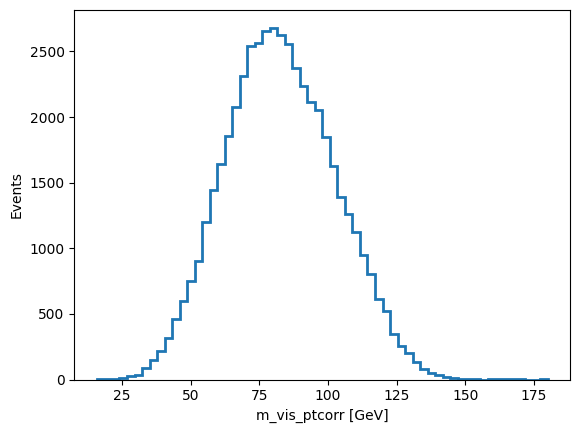

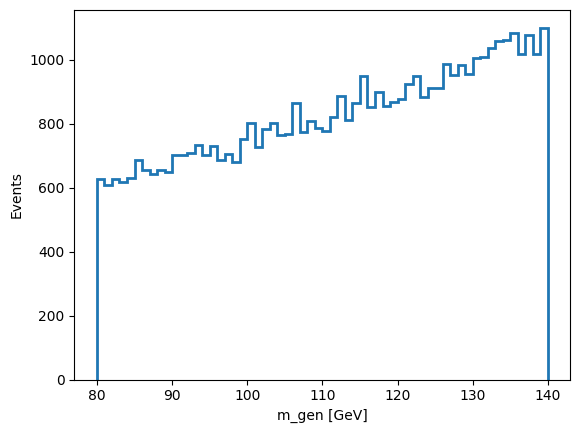

In [75]:
# taglio in massa -> su m_target
print("Before cut:", len(df_flat_event))

df_flat_cut = df_flat_event[
    (df_flat_event["m_gen"] >= 80.0) &
    (df_flat_event["m_gen"] <= 140.0)
].copy()

print("After cut:", len(df_flat_cut))

# just checking 
import matplotlib.pyplot as plt

plt.hist(df_flat_cut["m_vis_ptcorr"], bins=60, histtype = 'step', linewidth = 2, density = False)   
plt.xlabel("m_vis_ptcorr [GeV]")
plt.ylabel("Events")
plt.show()


plt.hist(df_flat_cut["m_gen"], bins=60, histtype = 'step', linewidth = 2, density = False)  # -> Me lo aspetto quasi piatto
plt.xlabel("m_gen [GeV]")
plt.ylabel("Events")
plt.show()

In [76]:
# Preparazione per training 

eps = 1e-8

# Li rinomino coerentemente con il precedente modello :
df_flat_cut["tau1_pt_gen"] = df_flat_cut["gen_tau1_pt"]
df_flat_cut["tau2_pt_gen"] = df_flat_cut["gen_tau2_pt"]

# --- target: fattore di correzione ---
df_flat_cut["tau1_corr"] = df_flat_cut["tau1_pt_gen"] / np.clip(df_flat_cut["tau1_pt_reco_corrPNet"], eps, None)
df_flat_cut["tau2_corr"] = df_flat_cut["tau2_pt_gen"] / np.clip(df_flat_cut["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]

In [77]:
missing = [c for c in train_cols + y_cols if c not in df_flat_cut.columns]
print("Missing columns:", missing)
print("N train cols:", len(train_cols))
print("df_flat_cut shape:", df_flat_cut.shape)

Missing columns: []
N train cols: 52
df_flat_cut shape: (49798, 78)


In [127]:
# ============================================================
# 0) Inference helper UNICO (global o separate) + mode robusto
# ============================================================
@torch.no_grad()
def predict_tau_corr(df, res, train_cols, y_cols, n_steps=60, class_col="class"):
    """
    Predice (tau1_corr, tau2_corr) usando lo scaler corretto:
      - scalers['mode'] == 'global'   : usa scalers['global']
      - scalers['mode'] == 'separate' : usa scalers['DY'] e scalers['Higgs'] in base a df[class_col]
    Ritorna df con colonne tau1_corr_pred, tau2_corr_pred
    """
    model   = res["model"]
    device  = res["device"]
    log_y   = res["log_y"]
    scalers = res["scalers"]

    def _run_block(df_block, xsc, ysc):
        X = xsc.transform(df_block[train_cols].to_numpy())
        X = torch.tensor(X, dtype=torch.float32, device=device)

        y_hat_s = sample_y(model, X, n_steps=n_steps, device=device)  # scaled (and maybe log)
        y_hat   = ysc.inverse_transform(y_hat_s.cpu().numpy())

        if log_y:
            y_hat = np.exp(y_hat)

        out = df_block.copy()
        out["tau1_corr_pred"] = y_hat[:, 0]
        out["tau2_corr_pred"] = y_hat[:, 1]
        return out

    mode = scalers.get("mode", None)

    if mode == "global":
        xsc = scalers["global"]["x"]
        ysc = scalers["global"]["y"]
        return _run_block(df, xsc, ysc)

    if mode == "separate":
        if class_col not in df.columns:
            raise ValueError("scalers['mode']='separate' ma df non ha la colonna class")

        df0 = df[df[class_col] == 0]
        df1 = df[df[class_col] == 1]

        out0 = _run_block(df0, scalers["DY"]["x"],    scalers["DY"]["y"])
        out1 = _run_block(df1, scalers["Higgs"]["x"], scalers["Higgs"]["y"])

        out = pd.concat([out0, out1], axis=0).sort_index()
        return out

    raise ValueError(f"scalers['mode'] non riconosciuto: {mode}")


In [128]:
# ============================================================
# 1) Preparazione arrays: global scaler (flat) oppure separate (DY/H)
# ============================================================
from sklearn.preprocessing import StandardScaler

def prepare_arrays_global_scaler(df_train, df_val, df_test, train_cols, y_cols, log_y=True):
    """Unico scaler globale (fit SOLO sul train)."""
    def get_Xy(df):
        X = df[train_cols].to_numpy()
        y = df[y_cols].to_numpy()
        if log_y:
            eps = 1e-12
            y = np.log(np.clip(y, eps, None))
        return X, y

    Xtr, ytr = get_Xy(df_train)
    Xva, yva = get_Xy(df_val)
    Xte, yte = get_Xy(df_test)

    xsc, ysc = StandardScaler(), StandardScaler()
    Xtr_s = xsc.fit_transform(Xtr)
    ytr_s = ysc.fit_transform(ytr)
    Xva_s = xsc.transform(Xva)
    yva_s = ysc.transform(yva)
    Xte_s = xsc.transform(Xte)
    yte_s = ysc.transform(yte)

    scalers = {
        "mode": "global",
        "global": {"x": xsc, "y": ysc},
        "log_y": bool(log_y),
    }
    return Xtr_s, Xva_s, Xte_s, ytr_s, yva_s, yte_s, scalers


def prepare_arrays_separate_scalers(
    df_train, df_val, df_test,
    train_cols, y_cols,
    class_col="class",
    log_y=True,
    seed=42,
):
    """Scalers separati per DY/H (fit SOLO sui rispettivi train)."""
    def get_Xy(df):
        X = df[train_cols].to_numpy()
        y = df[y_cols].to_numpy()
        if log_y:
            eps = 1e-12
            y = np.log(np.clip(y, eps, None))
        return X, y

    # split per class
    tr0 = df_train[df_train[class_col] == 0]
    tr1 = df_train[df_train[class_col] == 1]
    va0 = df_val[df_val[class_col] == 0]
    va1 = df_val[df_val[class_col] == 1]
    te0 = df_test[df_test[class_col] == 0]
    te1 = df_test[df_test[class_col] == 1]

    X0_tr, y0_tr = get_Xy(tr0)
    X1_tr, y1_tr = get_Xy(tr1)

    xsc0, ysc0 = StandardScaler(), StandardScaler()
    xsc1, ysc1 = StandardScaler(), StandardScaler()

    X0_tr_s = xsc0.fit_transform(X0_tr)
    y0_tr_s = ysc0.fit_transform(y0_tr)
    X1_tr_s = xsc1.fit_transform(X1_tr)
    y1_tr_s = ysc1.fit_transform(y1_tr)

    def transform_block(df, xsc, ysc):
        X, y = get_Xy(df)
        return xsc.transform(X), ysc.transform(y)

    X0_va_s, y0_va_s = transform_block(va0, xsc0, ysc0)
    X1_va_s, y1_va_s = transform_block(va1, xsc1, ysc1)
    X0_te_s, y0_te_s = transform_block(te0, xsc0, ysc0)
    X1_te_s, y1_te_s = transform_block(te1, xsc1, ysc1)

    rng = np.random.default_rng(seed)

    def concat_shuffle(Xa, Xb, ya, yb):
        X = np.concatenate([Xa, Xb], axis=0)
        y = np.concatenate([ya, yb], axis=0)
        idx = rng.permutation(len(X))
        return X[idx], y[idx]

    Xtr, ytr = concat_shuffle(X0_tr_s, X1_tr_s, y0_tr_s, y1_tr_s)
    Xva, yva = concat_shuffle(X0_va_s, X1_va_s, y0_va_s, y1_va_s)
    Xte, yte = concat_shuffle(X0_te_s, X1_te_s, y0_te_s, y1_te_s)

    scalers = {
        "mode": "separate",
        "DY":    {"x": xsc0, "y": ysc0},
        "Higgs": {"x": xsc1, "y": ysc1},
        "log_y": bool(log_y),
    }
    return Xtr, Xva, Xte, ytr, yva, yte, scalers


In [129]:
# ============================================================
# 2) Trainer con scaling_mode esplicito (evita ambiguità flat con 'class')
# ============================================================
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    scaling_mode="auto",        # <-- NEW: "auto" | "global" | "separate"
    seed=42,
    log_y=True,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
    print_every=10,
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    has_class = (class_col in df_use.columns)
    if scaling_mode == "auto":
        mode = "separate" if has_class else "global"
    else:
        mode = scaling_mode
        if mode == "separate" and not has_class:
            raise ValueError("scaling_mode='separate' ma df non ha class_col")
        # se mode == global e df ha class: ok, semplicemente ignoro class per lo scaling

    # --- split ---
    if has_class:
        df_train, df_val, df_test = split_80_10_10(df_use, class_col=class_col, seed=seed)
        if balanced:
            df_train = make_balanced_df(df_train, class_col=class_col, seed=seed)
        summarize_splits(df_train, df_val, df_test, class_col=class_col)
    else:
        df_train, df_tmp = train_test_split(df_use, test_size=0.20, random_state=seed, shuffle=True)
        df_val, df_test  = train_test_split(df_tmp, test_size=0.50, random_state=seed, shuffle=True)
        df_train = df_train.reset_index(drop=True)
        df_val   = df_val.reset_index(drop=True)
        df_test  = df_test.reset_index(drop=True)
        print("Split summary (no class)")
        print(f"  Train: {len(df_train):>8}")
        print(f"  Val  : {len(df_val):>8}")
        print(f"  Test : {len(df_test):>8}")
        if balanced:
            print("WARNING: balanced=True ignorato (no class).")

    # --- scaling ---
    if mode == "global":
        Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_global_scaler(
            df_train, df_val, df_test, train_cols, y_cols, log_y=log_y
        )
    else:
        Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_separate_scalers(
            df_train, df_val, df_test, train_cols, y_cols,
            class_col=class_col, log_y=log_y, seed=seed
        )

    # loaders
    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    # model
    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}
    best_epoch, best_val = None, np.inf

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())
        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())
        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch == 1) or (print_every and (epoch % print_every == 0)):
            print(f"[Epoch {epoch:4d}] train={train_loss:.4e} | val={val_loss:.4e} | mode={mode}")

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch

        if stopper.step(val_loss, model):
            print(f"Early stopping at epoch {epoch} (best epoch={best_epoch}, best val={best_val:.4e})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # final test loss
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "scalers": scalers,
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
    }


In [130]:
# ============================================================
# 3) FLAT pretraining (FORZANDO global) + save checkpoint
# ============================================================
res_flat = train_conditional_flow_matching(
    df_all=df_flat_cut,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,              # irrilevante nel flat
    scaling_mode="global",       # <-- dovrebbe togliere l'ambiguità
    lr=2e-4,
    max_epochs=300,
    patience=20,
    batch_size=2048,
    log_y=True,
    print_every=10,
)

fm_flat_pretraining = {
    "model_state": res_flat["model"].state_dict(),
    "scalers": res_flat["scalers"],      # mode=global
    "log_y": res_flat["log_y"],
    "train_cols": train_cols,
    "y_cols": y_cols,
    "best_epoch": res_flat["best_epoch"],
    "history": res_flat["history"],
    "arch": {"hidden": (256,256,256), "time_embed_dim": 64, "dropout": 0.0},
}

torch.save(fm_flat_pretraining, "fm_flat_pretraining.pt")
print("Saved: fm_flat_pretraining.pt")


Split summary (no class)
  Train:    39838
  Val  :     4980
  Test :     4980
[Epoch    1] train=1.9747e+00 | val=1.9248e+00 | mode=global
[Epoch   10] train=1.6379e+00 | val=1.6727e+00 | mode=global
[Epoch   20] train=1.3754e+00 | val=1.3339e+00 | mode=global
[Epoch   30] train=1.2610e+00 | val=1.2818e+00 | mode=global
[Epoch   40] train=1.2398e+00 | val=1.2348e+00 | mode=global
[Epoch   50] train=1.2274e+00 | val=1.2356e+00 | mode=global
[Epoch   60] train=1.2229e+00 | val=1.2327e+00 | mode=global
[Epoch   70] train=1.2253e+00 | val=1.2160e+00 | mode=global
[Epoch   80] train=1.2149e+00 | val=1.2206e+00 | mode=global
[Epoch   90] train=1.2048e+00 | val=1.2240e+00 | mode=global
[Epoch  100] train=1.1916e+00 | val=1.1993e+00 | mode=global
[Epoch  110] train=1.1930e+00 | val=1.2026e+00 | mode=global
[Epoch  120] train=1.1780e+00 | val=1.2184e+00 | mode=global
Early stopping at epoch 127 (best epoch=107, best val=1.1604e+00)
Saved: fm_flat_pretraining.pt


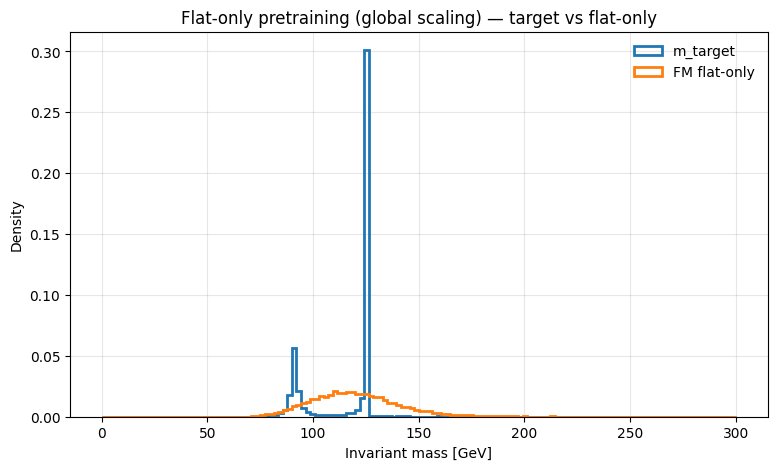

In [147]:
# ============================================================
# 4) Load checkpoint + inferenza flat-only su df_plot + masse + plot
# ============================================================
ckpt_flat = torch.load("fm_flat_pretraining.pt", map_location="cpu", weights_only=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

model_flat = ConditionalVelocityField(
    x_dim=len(ckpt_flat["y_cols"]),
    context_dim=len(ckpt_flat["train_cols"]),
    hidden=tuple(ckpt_flat["arch"]["hidden"]),
    time_embed_dim=int(ckpt_flat["arch"]["time_embed_dim"]),
    dropout=float(ckpt_flat["arch"]["dropout"]),
).to(device)

model_flat.load_state_dict(ckpt_flat["model_state"])
model_flat.eval()

res_flatonly = {
    "model": model_flat,
    "device": device,
    "scalers": ckpt_flat["scalers"],   # mode=global
    "log_y": ckpt_flat["log_y"],
}

df_pred_flat = predict_tau_corr(df_plot, res_flatonly, train_cols, y_cols, n_steps=60)

df_plot = df_plot.copy()
df_plot["tau1_corr_pred_flat"] = df_pred_flat["tau1_corr_pred"].values
df_plot["tau2_corr_pred_flat"] = df_pred_flat["tau2_corr_pred"].values

df_plot["tau1_pt_FM_flat"] = df_plot["tau1_pt_reco_corrPNet"] * df_plot["tau1_corr_pred_flat"]
df_plot["tau2_pt_FM_flat"] = df_plot["tau2_pt_reco_corrPNet"] * df_plot["tau2_corr_pred_flat"]

df_plot["inv_mass_FM_flatonly"] = inv_mass_two_objects(
    df_plot["tau1_pt_FM_flat"], df_plot["tau1_eta"], df_plot["tau1_phi"], df_plot["tau1_mass"],
    df_plot["tau2_pt_FM_flat"], df_plot["tau2_eta"], df_plot["tau2_phi"], df_plot["tau2_mass"],
)

plt.figure(figsize=(9,5))

plt.hist(df_plot["inv_mass_tar"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="m_target")
plt.hist(df_plot["inv_mass_FM_flatonly"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM flat-only")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.title("Flat-only pretraining (global scaling) — target vs flat-only")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.show()


In [133]:
# ============================================================
# FT-0) Estensione trainer: supporta init_state_dict (fine-tuning)
# ============================================================
def train_conditional_flow_matching(
    df_all,
    train_cols,
    y_cols,
    balanced: bool,
    class_col="class",
    scaling_mode="auto",          # "auto" | "global" | "separate"
    seed=42,
    log_y=True,
    batch_size=2048,
    hidden=(256, 256, 256),
    dropout=0.0,
    lr=2e-4,
    weight_decay=0.0,
    max_epochs=200,
    patience=15,
    min_delta=0.0,
    device=None,
    print_every=10,
    init_state_dict=None,         # <-- NEW
):
    set_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    df_use = df_all.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    has_class = (class_col in df_use.columns)
    if scaling_mode == "auto":
        mode = "separate" if has_class else "global"
    else:
        mode = scaling_mode
        if mode == "separate" and not has_class:
            raise ValueError("scaling_mode='separate' ma df non ha class_col")

    # --- split ---
    if has_class:
        df_train, df_val, df_test = split_80_10_10(df_use, class_col=class_col, seed=seed)
        if balanced:
            df_train = make_balanced_df(df_train, class_col=class_col, seed=seed)
        summarize_splits(df_train, df_val, df_test, class_col=class_col)
    else:
        df_train, df_tmp = train_test_split(df_use, test_size=0.20, random_state=seed, shuffle=True)
        df_val, df_test  = train_test_split(df_tmp, test_size=0.50, random_state=seed, shuffle=True)
        df_train = df_train.reset_index(drop=True)
        df_val   = df_val.reset_index(drop=True)
        df_test  = df_test.reset_index(drop=True)
        print("Split summary (no class)")
        print(f"  Train: {len(df_train):>8}")
        print(f"  Val  : {len(df_val):>8}")
        print(f"  Test : {len(df_test):>8}")
        if balanced:
            print("WARNING: balanced=True ignorato (no class).")

    # --- scaling ---
    if mode == "global":
        Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_global_scaler(
            df_train, df_val, df_test, train_cols, y_cols, log_y=log_y
        )
    else:
        Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_separate_scalers(
            df_train, df_val, df_test, train_cols, y_cols,
            class_col=class_col, log_y=log_y, seed=seed
        )

    # loaders
    train_loader = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TabularFMDataset(Xte, yte), batch_size=batch_size, shuffle=False)

    # model
    model = ConditionalVelocityField(
        x_dim=len(y_cols),
        context_dim=len(train_cols),
        hidden=hidden,
        time_embed_dim=64,
        dropout=dropout,
    ).to(device)

    # --- init weights from pretraining (fine-tuning) ---
    if init_state_dict is not None:
        missing, unexpected = model.load_state_dict(init_state_dict, strict=False)
        print(f"[init_state_dict] missing={len(missing)} unexpected={len(unexpected)}")
        if len(missing) > 0:
            print("  missing keys (first 10):", missing[:10])
        if len(unexpected) > 0:
            print("  unexpected keys (first 10):", unexpected[:10])

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = {"train_loss": [], "val_loss": []}
    best_epoch, best_val = None, np.inf

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())
        train_loss = float(np.mean(tr_losses)) if tr_losses else np.nan

        model.eval()
        va_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                loss = fm_loss(model, context=Xb, x1=yb, device=device)
                va_losses.append(loss.item())
        val_loss = float(np.mean(va_losses)) if va_losses else np.nan

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch == 1) or (print_every and (epoch % print_every == 0)):
            print(f"[Epoch {epoch:4d}] train={train_loss:.4e} | val={val_loss:.4e} | mode={mode}")

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch

        if stopper.step(val_loss, model):
            print(f"Early stopping at epoch {epoch} (best epoch={best_epoch}, best val={best_val:.4e})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # final test loss
    model.eval()
    te_losses = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model, context=Xb, x1=yb, device=device)
            te_losses.append(loss.item())
    test_loss = float(np.mean(te_losses)) if te_losses else np.nan

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "scalers": scalers,
        "log_y": log_y,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
        "scaling_mode_used": mode,
    }


In [134]:
# ============================================================
# FT-1) Carico checkpoint FLAT-only (pretraining)
# ============================================================
ckpt_flat = torch.load("fm_flat_pretraining.pt", map_location="cpu", weights_only=False)

print("Flat ckpt keys:", ckpt_flat.keys())
print("Flat scalers mode:", ckpt_flat["scalers"].get("mode"))
print("Flat best_epoch:", ckpt_flat.get("best_epoch"))


# ============================================================
# FT-2) Dataset fine-tuning = DY + Higgs (con class), unbalanced o balanced
# ============================================================
df_all = pd.concat([df_DY_event, df_H_event], axis=0).reset_index(drop=True)

# sanity check
print("df_all size:", len(df_all))
print("class counts:\n", df_all["class"].value_counts())

# ============================================================
# FT-3) Fine-tuning su DY+H con SCALING SEPARATI
#      (unbalanced)
# ============================================================
res_finetune_unbal = train_conditional_flow_matching(
    df_all=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    balanced=False,                 # unbalanced
    scaling_mode="separate",        
    init_state_dict=ckpt_flat["model_state"],   # <-- start from flat weights
    lr=5e-5,                         # lr più basso per fine-tuning
    max_epochs=200,
    patience=20,
    batch_size=2048,
    log_y=True,
    print_every=10,
)

print("FINETUNE (unbalanced) test loss:", res_finetune_unbal["test_loss"])


Flat ckpt keys: dict_keys(['model_state', 'scalers', 'log_y', 'train_cols', 'y_cols', 'best_epoch', 'history', 'arch'])
Flat scalers mode: global
Flat best_epoch: 107
df_all size: 179459
class counts:
 class
1    128034
0     51425
Name: count, dtype: int64
Split summary
  Train:   143567  frac: {1: 0.713, 0: 0.287}
  Val  :    17946  frac: {1: 0.713, 0: 0.287}
  Test :    17946  frac: {1: 0.713, 0: 0.287}
[init_state_dict] missing=0 unexpected=0
[Epoch    1] train=1.3071e+00 | val=1.2772e+00 | mode=separate
[Epoch   10] train=1.1948e+00 | val=1.2140e+00 | mode=separate
[Epoch   20] train=1.1674e+00 | val=1.1662e+00 | mode=separate
[Epoch   30] train=1.1160e+00 | val=1.1293e+00 | mode=separate
[Epoch   40] train=1.0777e+00 | val=1.0974e+00 | mode=separate
[Epoch   50] train=1.0615e+00 | val=1.0918e+00 | mode=separate
[Epoch   60] train=1.0487e+00 | val=1.0627e+00 | mode=separate
[Epoch   70] train=1.0476e+00 | val=1.0755e+00 | mode=separate
[Epoch   80] train=1.0359e+00 | val=1.0575e+0

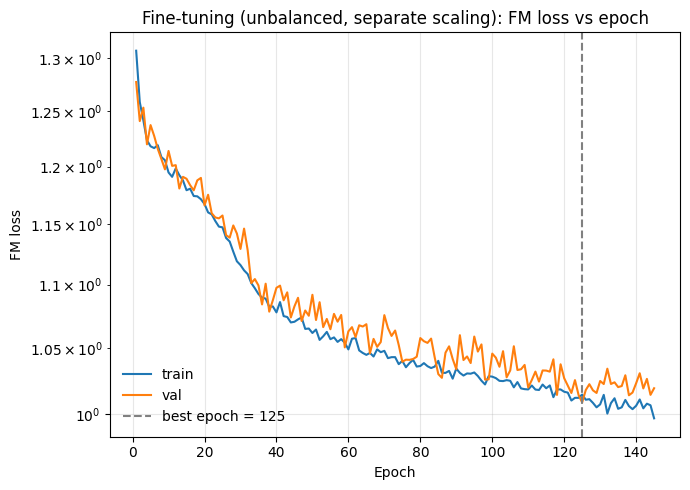

In [136]:
# ============================================================
# FT-3b) Plot delle loss vs epoche (fine-tuning unbalanced)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def plot_history(res, title=""):
    hist = res["history"]
    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["train_loss"], label="train")
    plt.plot(epochs, hist["val_loss"], label="val")

    be = res.get("best_epoch", None)
    if be is not None:
        plt.axvline(be, linestyle="--", color="gray", label=f"best epoch = {be}")

    plt.xlabel("Epoch")
    plt.ylabel("FM loss")
    plt.yscale("log")   # molto utile per vedere la stabilità
    plt.title(title)
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_history(
    res_finetune_unbal,
    title="Fine-tuning (unbalanced, separate scaling): FM loss vs epoch"
)


Saved: fm_finetuned_unbalanced.pt


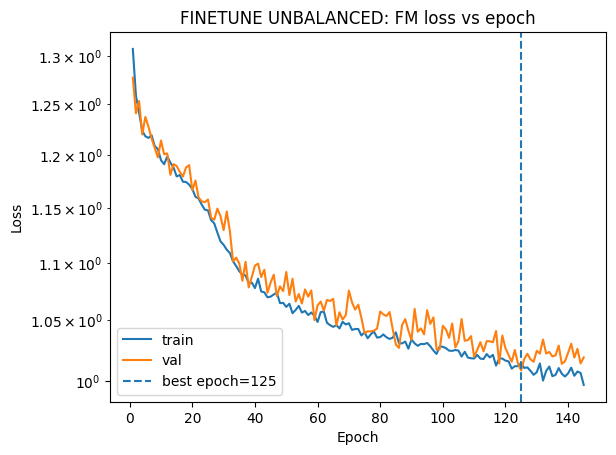

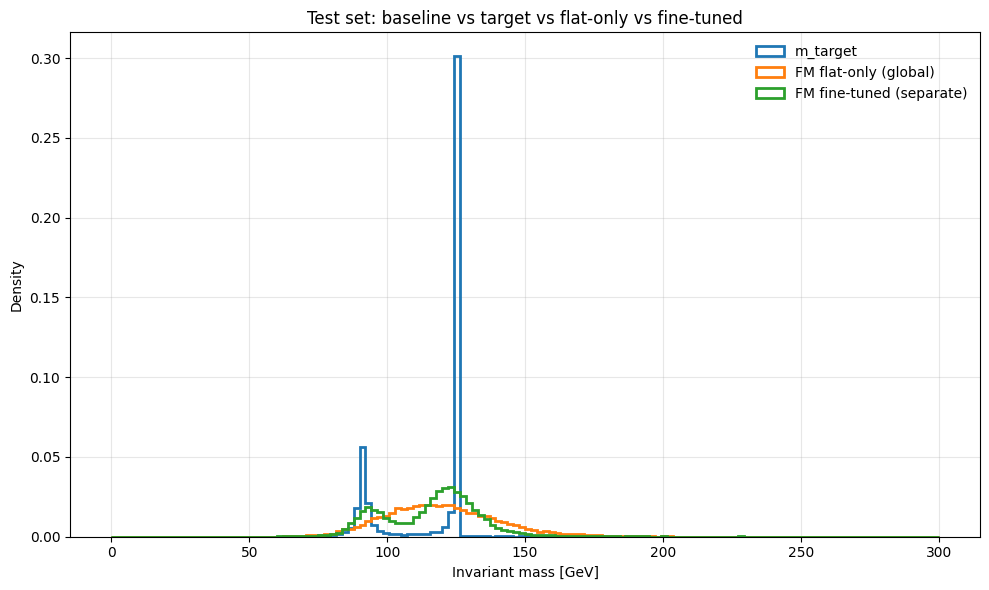

In [135]:
# ============================================================
# FT-4) Salvo checkpoint fine-tuned
# ============================================================
fm_finetuned_unbalanced = {
    "model_state": res_finetune_unbal["model"].state_dict(),
    "scalers": res_finetune_unbal["scalers"],   # mode=separate
    "log_y": res_finetune_unbal["log_y"],
    "train_cols": train_cols,
    "y_cols": y_cols,
    "best_epoch": res_finetune_unbal["best_epoch"],
    "history": res_finetune_unbal["history"],
    "scaling_mode_used": res_finetune_unbal["scaling_mode_used"],
    "init_from": "fm_flat_pretraining.pt",
}

torch.save(fm_finetuned_unbalanced, "fm_finetuned_unbalanced.pt")
print("Saved: fm_finetuned_unbalanced.pt")

# ============================================================
# FT-5) Curve di training (fine-tuning)
# ============================================================
plot_history(res_finetune_unbal, "FINETUNE UNBALANCED: FM loss vs epoch")

# ============================================================
# FT-6) Inference sul TEST set + masse: baseline vs target vs flat-only vs fine-tuned
# ============================================================
# prendo il test set del fine-tuning (così è clean)
df_train_ft, df_val_ft, df_test_ft = res_finetune_unbal["df_splits"]
df_plot_ft = df_test_ft.copy()

# --- (A) Flat-only prediction (global scaler) ---
device = res_finetune_unbal["device"]
model_flat = ConditionalVelocityField(
    x_dim=len(ckpt_flat["y_cols"]),
    context_dim=len(ckpt_flat["train_cols"]),
    hidden=(256, 256, 256),
    time_embed_dim=64,
    dropout=0.0,
).to(device)
model_flat.load_state_dict(ckpt_flat["model_state"])
model_flat.eval()

res_flatonly = {
    "model": model_flat,
    "device": device,
    "scalers": ckpt_flat["scalers"],   # mode=global
    "log_y": ckpt_flat["log_y"],
}

df_pred_flat = predict_tau_corr(df_plot_ft, res_flatonly, train_cols, y_cols, n_steps=60)
df_plot_ft["tau1_corr_pred_flat"] = df_pred_flat["tau1_corr_pred"].values
df_plot_ft["tau2_corr_pred_flat"] = df_pred_flat["tau2_corr_pred"].values

df_plot_ft["tau1_pt_FM_flat"] = df_plot_ft["tau1_pt_reco_corrPNet"] * df_plot_ft["tau1_corr_pred_flat"]
df_plot_ft["tau2_pt_FM_flat"] = df_plot_ft["tau2_pt_reco_corrPNet"] * df_plot_ft["tau2_corr_pred_flat"]

df_plot_ft["inv_mass_FM_flatonly"] = inv_mass_two_objects(
    df_plot_ft["tau1_pt_FM_flat"], df_plot_ft["tau1_eta"], df_plot_ft["tau1_phi"], df_plot_ft["tau1_mass"],
    df_plot_ft["tau2_pt_FM_flat"], df_plot_ft["tau2_eta"], df_plot_ft["tau2_phi"], df_plot_ft["tau2_mass"],
)

# --- (B) Fine-tuned prediction (separate scalers) ---
df_pred_ft = predict_tau_corr(df_plot_ft, res_finetune_unbal, train_cols, y_cols, n_steps=60)
df_plot_ft["tau1_corr_pred_ft"] = df_pred_ft["tau1_corr_pred"].values
df_plot_ft["tau2_corr_pred_ft"] = df_pred_ft["tau2_corr_pred"].values

df_plot_ft["tau1_pt_FM_ft"] = df_plot_ft["tau1_pt_reco_corrPNet"] * df_plot_ft["tau1_corr_pred_ft"]
df_plot_ft["tau2_pt_FM_ft"] = df_plot_ft["tau2_pt_reco_corrPNet"] * df_plot_ft["tau2_corr_pred_ft"]

df_plot_ft["inv_mass_FM_finetuned"] = inv_mass_two_objects(
    df_plot_ft["tau1_pt_FM_ft"], df_plot_ft["tau1_eta"], df_plot_ft["tau1_phi"], df_plot_ft["tau1_mass"],
    df_plot_ft["tau2_pt_FM_ft"], df_plot_ft["tau2_eta"], df_plot_ft["tau2_phi"], df_plot_ft["tau2_mass"],
)

# --- Plot finale (non metto m_reco) ---
plt.figure(figsize=(10,6))
#plt.hist(df_plot_ft["inv_mass_reco"], bins=140, range=(0,300),
#         histtype="step", density=True, lw=2, label="m_reco (baseline)")
plt.hist(df_plot_ft["inv_mass_tar"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="m_target")
plt.hist(df_plot_ft["inv_mass_FM_flatonly"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM flat-only (global)")
plt.hist(df_plot_ft["inv_mass_FM_finetuned"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2, label="FM fine-tuned (separate)")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.title("Test set: baseline vs target vs flat-only vs fine-tuned")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [137]:
# ============================================================
# FT-6bis) Predizione con modello UNBALANCED (from scratch)
# ============================================================
df_pred_unbal = predict_tau_corr(
    df_plot_ft,
    res_unbalanced,      # <-- modello unbalanced "vecchio"
    train_cols,
    y_cols,
    n_steps=60
)

df_plot_ft["tau1_corr_pred_unbal"] = df_pred_unbal["tau1_corr_pred"].values
df_plot_ft["tau2_corr_pred_unbal"] = df_pred_unbal["tau2_corr_pred"].values

df_plot_ft["tau1_pt_FM_unbal"] = (
    df_plot_ft["tau1_pt_reco_corrPNet"] * df_plot_ft["tau1_corr_pred_unbal"]
)
df_plot_ft["tau2_pt_FM_unbal"] = (
    df_plot_ft["tau2_pt_reco_corrPNet"] * df_plot_ft["tau2_corr_pred_unbal"]
)

df_plot_ft["inv_mass_FM_unbalanced"] = inv_mass_two_objects(
    df_plot_ft["tau1_pt_FM_unbal"], df_plot_ft["tau1_eta"],
    df_plot_ft["tau1_phi"],        df_plot_ft["tau1_mass"],
    df_plot_ft["tau2_pt_FM_unbal"], df_plot_ft["tau2_eta"],
    df_plot_ft["tau2_phi"],        df_plot_ft["tau2_mass"],
)


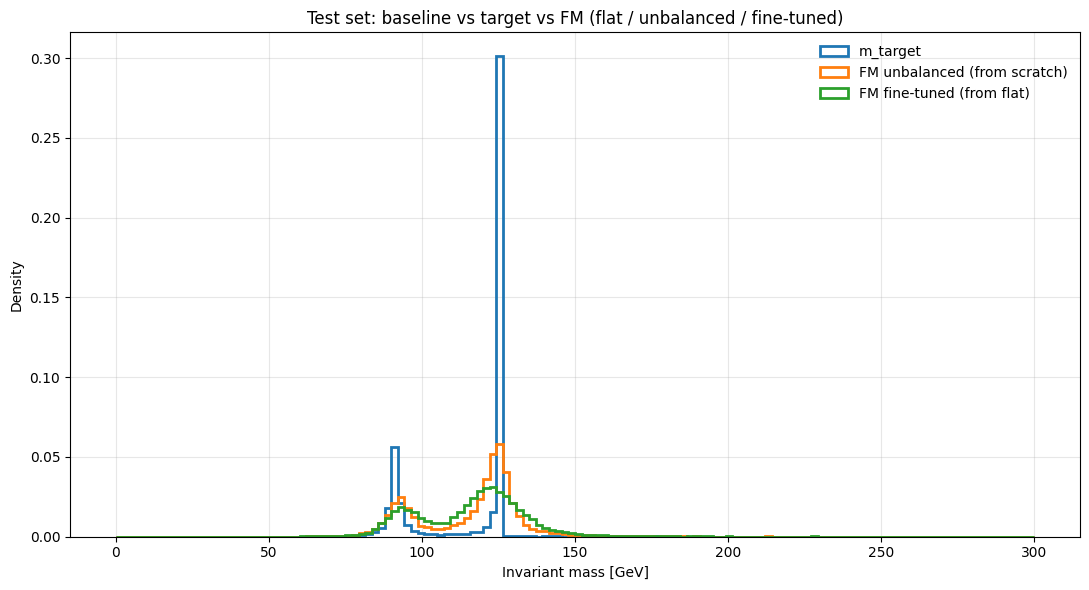

In [140]:
# ============================================================
# FT-7) Plot finale: baseline vs target vs tutti i modelli
# ============================================================
plt.figure(figsize=(11,6))


plt.hist(df_plot_ft["inv_mass_tar"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2,
         label="m_target")

plt.hist(df_plot_ft["inv_mass_FM_unbalanced"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2,
         label="FM unbalanced (from scratch)")

plt.hist(df_plot_ft["inv_mass_FM_finetuned"], bins=140, range=(0,300),
         histtype="step", density=True, lw=2,
         label="FM fine-tuned (from flat)")

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Density")
plt.title("Test set: baseline vs target vs FM (flat / unbalanced / fine-tuned)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [142]:
# ============================================================
# Tabella quantitativa: target vs modelli FM
# ============================================================
def build_comparison_table(
    df,
    mass_cols_dict,
    class_col="class",
    h_win=(110,140),
    kl_bins=140,
    kl_range=(70,140),
):
    """
    mass_cols_dict = {
        "Target": "inv_mass_tar",
        "FM unbalanced": "inv_mass_FM_unbalanced",
        "FM fine-tuned": "inv_mass_FM_finetuned",
        "FM flat-only": "inv_mass_FM_flatonly",   # opzionale
    }
    """
    rows = []

    for name, col in mass_cols_dict.items():
        rows.append({
            "Training": name,
            f"S/B (H window {h_win[0]}–{h_win[1]})":
                compute_SB_in_fixed_windows(
                    df, col, class_col=class_col, h_win=h_win
                ),
            f"KL(H || DY) [{kl_range[0]}–{kl_range[1]}]":
                compute_KL_divergence_hist(
                    df, col, class_col=class_col,
                    bins=kl_bins, mass_range=kl_range
                ),
            "EMD(H, DY) [GeV]":
                compute_EMD(df, col, class_col=class_col),
        })

    out = pd.DataFrame(rows)

    sb_col = f"S/B (H window {h_win[0]}–{h_win[1]})"
    kl_col = f"KL(H || DY) [{kl_range[0]}–{kl_range[1]}]"

    out[sb_col] = out[sb_col].replace(np.inf, np.nan).astype(float).round(3)
    out[kl_col] = out[kl_col].astype(float).round(3)
    out["EMD(H, DY) [GeV]"] = out["EMD(H, DY) [GeV]"].astype(float).round(3)

    return out



metrics_comparison = build_comparison_table(
    df_plot_ft,
    mass_cols_dict={
        "Target": "inv_mass_tar",
        "FM unbalanced (from scratch)": "inv_mass_FM_unbalanced",
        "FM fine-tuned (from flat)": "inv_mass_FM_finetuned",
        # non penso di volerlo mettere, però:
        # "FM flat-only": "inv_mass_FM_flatonly",
    },
    class_col="class",
    h_win=(110,140),
    kl_bins=140,
    kl_range=(70,140),
)

metrics_comparison



,Training,S/B (H window 110–140),KL(H || DY) [70–140],"EMD(H, DY) [GeV]"
0,Target,77.341,13.159,31.969
1,FM unbalanced (from scratch),51.950,9.338,28.935
2,FM fine-tuned (from flat),44.054,7.544,26.527
